# Part 1 Analysis - Gita

In [ ]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
import numpy as np
import hvplot.pandas
import plotly.express as px

In [2]:
#to find the path
melb_data = Path ("melb_data1fixed.csv")

In [3]:
#to read the file
melhousing_df = pd.read_csv(melb_data)
melhousing_df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lat,Long,Regionname,Propertycount,Year
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,12/3/2016,2.5,3067,...,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016.0
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2/4/2016,2.5,3067,...,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,2016.0
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,3/4/2017,2.5,3067,...,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,2017.0
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,3/4/2017,2.5,3067,...,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019,2017.0
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,6/4/2016,2.5,3067,...,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019,2016.0


In [4]:
#count the rows for each column
melhousing_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
BuildingArea      7130
YearBuilt         8205
CouncilArea      12212
Lat              13580
Long             13580
Regionname       13580
Propertycount    13580
Year             13560
dtype: int64

In [5]:
#to drop the column that has a lot of empty row to avoid bias analysis
melhousingclean_df=melhousing_df.drop(["BuildingArea","YearBuilt"],axis=1)
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
CouncilArea      12212
Lat              13580
Long             13580
Regionname       13580
Propertycount    13580
Year             13560
dtype: int64

In [6]:
#to fill the row that has empty row with the value in the row before
melhousingclean_df[['CouncilArea', 'Car']] = melhousingclean_df[['CouncilArea', 'Car']].fillna(method='ffill')

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3496885142.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  melhousingclean_df[['CouncilArea', 'Car']] = melhousingclean_df[['CouncilArea', 'Car']].fillna(method='ffill')


In [7]:
#to check all the columns has the same number of row data
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13580
Landsize         13580
CouncilArea      13580
Lat              13580
Long             13580
Regionname       13580
Propertycount    13580
Year             13560
dtype: int64

In [8]:
#change the date colummn data type from object to datetime
#melhousingclean_df['Date'] = pd.to_datetime(melhousingclean_df['Date'], dayfirst=True)
print(melhousingclean_df['Date'].dtype)

object


In [9]:
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13580
Landsize         13580
CouncilArea      13580
Lat              13580
Long             13580
Regionname       13580
Propertycount    13580
Year             13560
dtype: int64

In [10]:
#visualize the data using bar and pie
#to find top 5 agent by volume price and bottom 5 agent, to find how many houses the agent sold

In [11]:
#to rename to colomn
melhousingclean_df.rename(columns={'SellerG' : 'PropertyAgent'}, inplace=True)
melhousingclean_df

,Suburb,Address,Rooms,Type,Price,Method,PropertyAgent,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lat,Long,Regionname,Propertycount,Year
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,12/3/2016,2.5,3067,2,1,1.0,202,Yarra,-37.79960,144.99840,Northern Metropolitan,4019,2016.0
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2/4/2016,2.5,3067,2,1,0.0,156,Yarra,-37.80790,144.99340,Northern Metropolitan,4019,2016.0
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,3/4/2017,2.5,3067,3,2,0.0,134,Yarra,-37.80930,144.99440,Northern Metropolitan,4019,2017.0
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,3/4/2017,2.5,3067,3,2,1.0,94,Yarra,-37.79690,144.99690,Northern Metropolitan,4019,2017.0
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,6/4/2016,2.5,3067,3,1,2.0,120,Yarra,-37.80720,144.99410,Northern Metropolitan,4019,2016.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000,S,Barry,8/26/2017,16.7,3150,4,2,2.0,652,Maribyrnong,-37.90562,145.16761,South-Eastern Metropolitan,7392,2017.0
13576,Williamstown,77 Merrett Dr,3,h,1031000,SP,Williams,8/26/2017,6.8,3016,3,2,2.0,333,Maribyrnong,-37.85927,144.87904,Western Metropolitan,6380,2017.0
13577,Williamstown,83 Power St,3,h,1170000,S,Raine,8/26/2017,6.8,3016,3,2,4.0,436,Maribyrnong,-37.85274,144.88738,Western Metropolitan,6380,2017.0
13578,Williamstown,96 Verdon St,4,h,2500000,PI,Sweeney,8/26/2017,6.8,3016,4,1,5.0,866,Maribyrnong,-37.85908,144.89299,Western Metropolitan,6380,2017.0


In [12]:
total_house_sold = melhousingclean_df['Address'].count()
print (f"Total of house sold is : {total_house_sold}")

Total of house sold is : 13580


In [13]:
duplicate_address_data = melhousingclean_df.loc[melhousingclean_df["Address"].isin(['7 Wallace St', '16 Park Rd', '7 Victoria St', '69 Victoria St', '8 Vickery St'])]
print(duplicate_address_data)


              Suburb         Address  Rooms Type    Price Method  \
827   Bentleigh East    7 Wallace St      3    h  1355000      S   
3731       Maidstone    7 Wallace St      3    h   721000      S   
4818         Prahran      16 Park Rd      3    t  1245000     PI   
5780        St Kilda   7 Victoria St      3    h  2000000     VB   
6123    Surrey Hills      16 Park Rd      2    h  1018000      S   
6495    Williamstown   7 Victoria St      4    h  2640000      S   
7769          Coburg  69 Victoria St      3    t   720000     PI   
7770          Coburg  69 Victoria St      3    t   720000     PI   
9793       Bentleigh    8 Vickery St      5    h  1900000     VB   
9948    Malvern East    8 Vickery St      4    h  3600000      S   

          PropertyAgent       Date  Distance  Postcode  Bedroom2  Bathroom  \
827              Buxton  10/8/2016      13.9      3165         0         1   
3731  Sweeney/Advantage  10/8/2016       9.2      3012         2         2   
4818           Ma

In [14]:
#to count how many property agents in Melb
melb_agent = melhousingclean_df['PropertyAgent'].value_counts()
melb_agent

PropertyAgent
Nelson           1565
Jellis           1316
hockingstuart    1167
Barry            1011
Ray               701
                 ... 
Prowse              1
Luxe                1
Zahn                1
Homes               1
Point               1
Name: count, Length: 268, dtype: int64

In [15]:
#to find top 5 most selling agents
#identifying high-volume sellers by price
melb_agent_total = melhousingclean_df.groupby('PropertyAgent')['Price'].sum().sort_values(ascending=False).head(5)
melb_agent_total

PropertyAgent
Jellis           1800503098
Nelson           1588438150
Marshall         1244748138
hockingstuart    1114166699
Barry             885942476
Name: Price, dtype: int64

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/2488675089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=melb_agent_total.index, y=melb_agent_total.values, palette='magma')


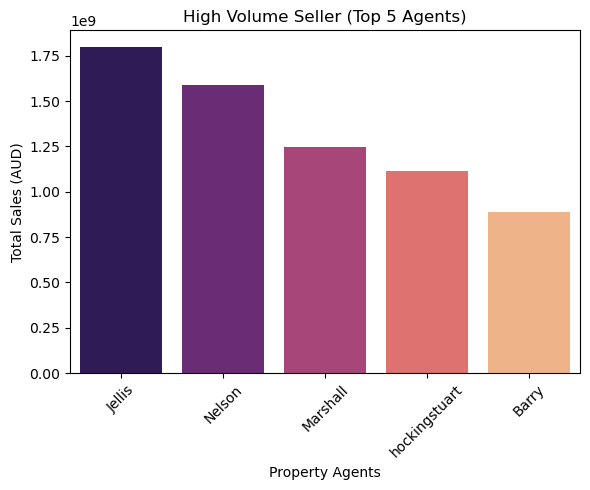

In [16]:
#chart for top 5 most selling agents
plt.figure(figsize=(6, 5))
sns.barplot(x=melb_agent_total.index, y=melb_agent_total.values, palette='magma')

plt.title('High Volume Seller (Top 5 Agents)')
plt.xlabel('Property Agents')
plt.ylabel('Total Sales (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [17]:
#to count how many houses the agent sold 
top_five = ['Jellis', 'Nelson', 'Marshall', 'hockingstuart', 'Barry']
total_house = melhousingclean_df[melhousingclean_df['PropertyAgent'].isin(top_five)]
melb_agent_total_house = total_house['PropertyAgent'].value_counts()
melb_agent_total_house

PropertyAgent
Nelson           1565
Jellis           1316
hockingstuart    1167
Barry            1011
Marshall          659
Name: count, dtype: int64

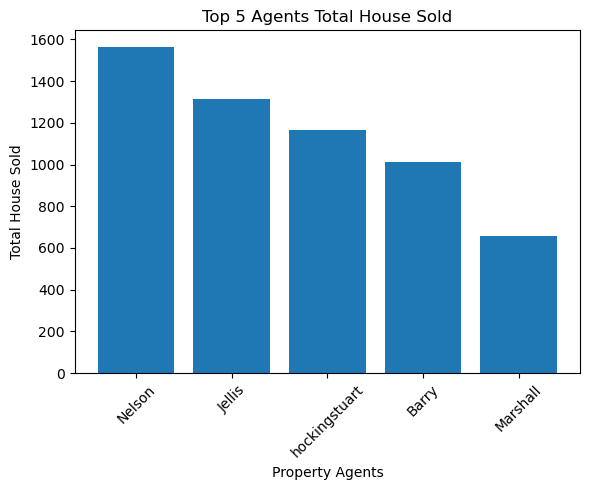

In [18]:
#to show how many houses the agent sold 
plt.figure(figsize=(6, 5))
plt.bar(melb_agent_total_house.index, melb_agent_total_house.values, alpha=1.0, facecolor='#1f77b4', align="center")

plt.title('Top 5 Agents Total House Sold')
plt.xlabel('Property Agents')
plt.ylabel('Total House Sold')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [19]:
#identifying bottom 5-volume agents
melb_agent_total_last = melhousingclean_df.groupby('PropertyAgent')['Price'].sum().sort_values(ascending=True).head(5)
melb_agent_total_last

PropertyAgent
Rosin                      330000
hockingstuart/Advantage    330000
hockingstuart/Village      345000
Wood                       370000
Oak                        380000
Name: Price, dtype: int64

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3769633204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=melb_agent_total_last.index, y=melb_agent_total_last.values, palette='magma')


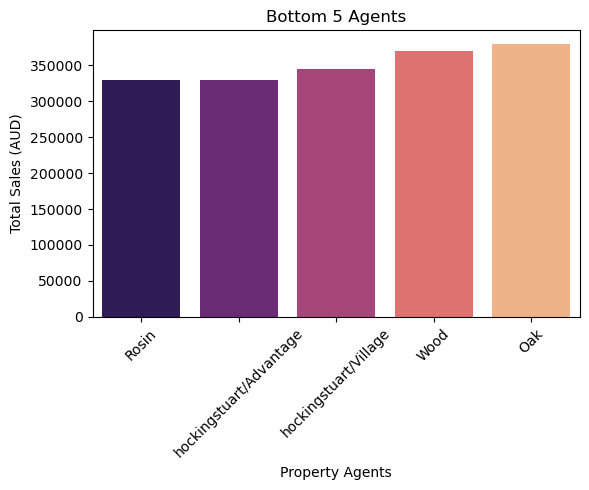

In [20]:
#chart for bottom 5 volume agents
plt.figure(figsize=(6, 5))
sns.barplot(x=melb_agent_total_last.index, y=melb_agent_total_last.values, palette='magma')

plt.title('Bottom 5 Agents')
plt.xlabel('Property Agents')
plt.ylabel('Total Sales (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
#to count how many house the agent sold for bottom 5
bottom_five = ['Rosin', 'hockingstuart/Advantage', 'hockingstuart/Village', 'Wood', 'Oak']
total_bottom_house = melhousingclean_df[melhousingclean_df['PropertyAgent'].isin(bottom_five)]
melb_agent_bottom_house = total_bottom_house['PropertyAgent'].value_counts()
melb_agent_bottom_house
#there is no need to visualize the data

PropertyAgent
hockingstuart/Advantage    1
Wood                       1
hockingstuart/Village      1
Oak                        1
Rosin                      1
Name: count, dtype: int64

In [22]:
#BONUS INFORMATION
#to find top 5 agent by average total sell
#to represent agents who may deal in higher-end properties, show the possibility that agents sell luxury property
melb_agent_avg = melhousingclean_df.groupby('PropertyAgent')['Price'].mean().sort_values(ascending=False).head(5)
melb_agent_avg

PropertyAgent
Weast        3.320000e+06
Darras       2.950000e+06
VICProp      2.797667e+06
Sotheby's    2.453750e+06
Lucas        2.450000e+06
Name: Price, dtype: float64

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3130921094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=melb_agent_avg.index, y=melb_agent_avg.values, palette='magma')


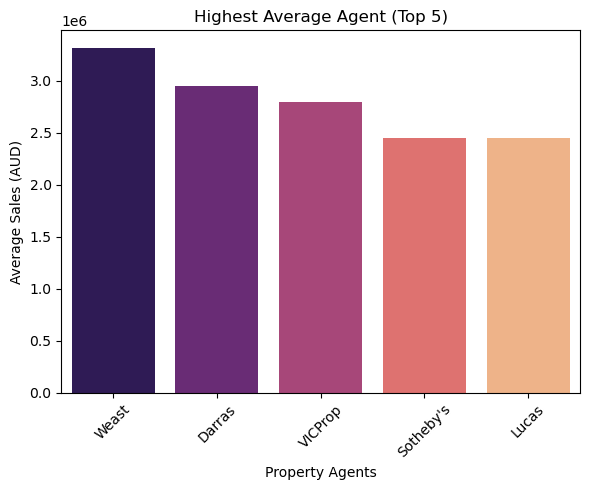

In [23]:
#chart for top 5 agent by average sales
plt.figure(figsize=(6, 5))
sns.barplot(x=melb_agent_avg.index, y=melb_agent_avg.values, palette='magma')

plt.title('Highest Average Agent (Top 5)')
plt.xlabel('Property Agents')
plt.ylabel('Average Sales (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
#to count how many house the agent sold 
avg_five = ["Weast", "Darras", "VICProp", "Sotheby's", "Lucas"]
avg_total_house = melhousingclean_df[melhousingclean_df['PropertyAgent'].isin(avg_five)]
melb_agent_avg_house = avg_total_house['PropertyAgent'].value_counts()
melb_agent_avg_house
#there is no need to make a visualization of data

PropertyAgent
Sotheby's    6
VICProp      3
Weast        1
Lucas        1
Darras       1
Name: count, dtype: int64

In [25]:
#FIND HOW MANY HOUSES SOLD PER YEAR

In [26]:
#to get the information of NaN row in year column
nan_count = melhousingclean_df['Year'].isna().sum()
nan_count

20

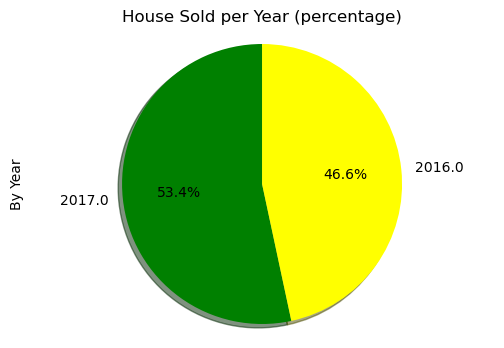

In [27]:
#to find the percentage of house sold in each year with pie chart using pyplot
house_sold_per_year = melhousingclean_df['Year'].value_counts()
#explode=(0.1)

plt.figure(figsize=(6, 4))
plt.pie(house_sold_per_year,
        #explode=explode,
        labels=house_sold_per_year.index, 
        autopct='%1.1f%%',
        startangle=90,
        shadow=True,
        colors=['green', 'yellow'])

plt.title('House Sold per Year (percentage)')
plt.ylabel('By Year')
plt.axis('equal')
plt.show()

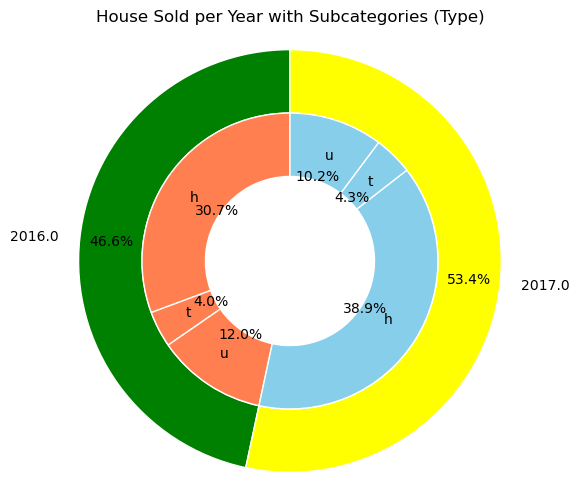

In [28]:
#to visualize the percentage of property types sold for each year
#groupby Year and Type
house_percent = melhousingclean_df.groupby(['Year', 'Type']).size()
inner_colors = ['coral', 'coral', 'coral', 'skyblue', 'skyblue', 'skyblue']

#create the outer and inner pie chart data
outer_labels = house_percent.index.get_level_values(0).unique()  # Years
inner_labels = house_percent.index.get_level_values(1)  # Types
outer_values = house_percent.groupby(level=0).sum()  # Total counts per year
inner_values = house_percent.values  # Counts for each type within the years

#create the nested pie chart
fig, ax = plt.subplots(figsize=(6, 6))

# create the outer pie (for years)
ax.pie(outer_values, labels=outer_labels, radius=1, autopct='%1.1f%%', startangle=90,
       pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'), colors=['green', 'yellow'])

# create the inner pie (for property types)
ax.pie(inner_values, labels=inner_labels, radius=0.7, autopct='%1.1f%%', startangle=90, 
       labeldistance=0.75, wedgeprops=dict(width=0.3, edgecolor='w'), colors=inner_colors)

# to add title and display the plot
plt.title('House Sold per Year with Subcategories (Type)')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

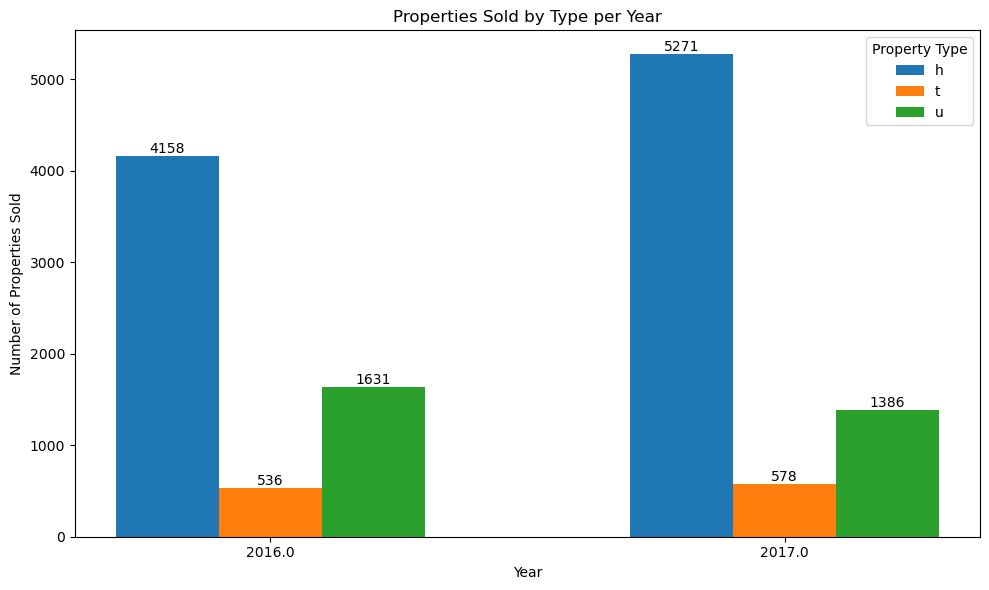

In [29]:
#to visualize how many property types sold for each year in bar plot

# group data by year and type
house_per_year = melhousingclean_df.groupby(['Year', 'Type']).size().reset_index(name='Count')

#plot data, create figure
plt.figure(figsize=(10, 6))

property_types = house_per_year['Type'].unique()
years = house_per_year['Year'].unique()

bar_width = 0.2
positions = list(range(len(years)))

for i, property_type in enumerate(property_types):
    subset = house_per_year[house_per_year['Type'] == property_type]
    bars = plt.bar([p + i * bar_width for p in positions], subset['Count'], width=bar_width, label=property_type)
    
    # to add counts number for each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Number of Properties Sold')
plt.title('Properties Sold by Type per Year')
plt.xticks([p + bar_width for p in positions], years)
plt.legend(title='Property Type')

# Display the chart
plt.tight_layout()
plt.show()

In [30]:
#find the relation of house distance from CBD to house price by all 8 regions in Melbourne

In [31]:
#find how many category of distances
distance = melhousingclean_df['Distance'].value_counts()
distance

Distance
11.2    739
9.2     367
13.9    324
7.8     306
4.6     263
       ... 
37.5      1
29.3      1
47.4      1
39.8      1
48.1      1
Name: count, Length: 202, dtype: int64

In [32]:
#find all the region with groupby to see the houses' distance from cbd in that region
region_distance = melhousingclean_df.groupby('Regionname')['Distance'].value_counts()
region_distance

Regionname            Distance
Eastern Metropolitan  13.8        99
                      13.9        89
                      11.8        83
                      7.9         80
                      10.5        60
                                  ..
Western Metropolitan  23.8         2
                      27.7         2
Western Victoria      29.8        19
                      31.7        12
                      37.5         1
Name: count, Length: 285, dtype: int64

In [33]:
region_names = melhousingclean_df['Regionname'].value_counts()
region_names

Regionname
Southern Metropolitan         4695
Northern Metropolitan         3890
Western Metropolitan          2948
Eastern Metropolitan          1471
South-Eastern Metropolitan     450
Eastern Victoria                53
Northern Victoria               41
Western Victoria                32
Name: count, dtype: int64

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/1610217272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Regionname', y='Distance', data=melhousingclean_df, palette='magma')


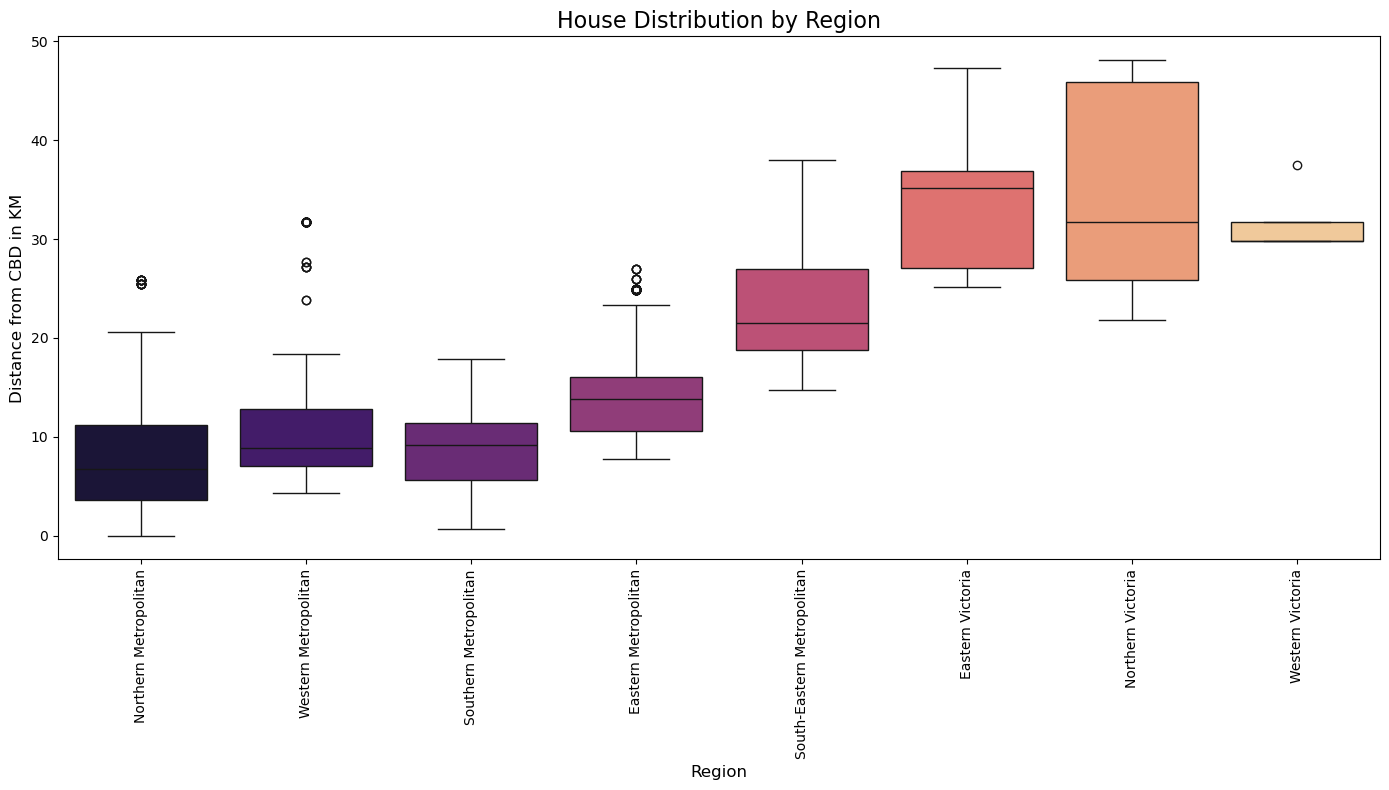

In [34]:
#set the figure
plt.figure(figsize=(14, 8))

#create boxplot
sns.boxplot(x='Regionname', y='Distance', data=melhousingclean_df, palette='magma')

#add title and labels
plt.title('House Distribution by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Distance from CBD in KM', fontsize=12)
plt.xticks(rotation=90) 
plt.tight_layout() #to make the layout tidy


#show the plot
plt.show()

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3750260871.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Regionname', y='Price', data=melhousingclean_df, palette='magma')


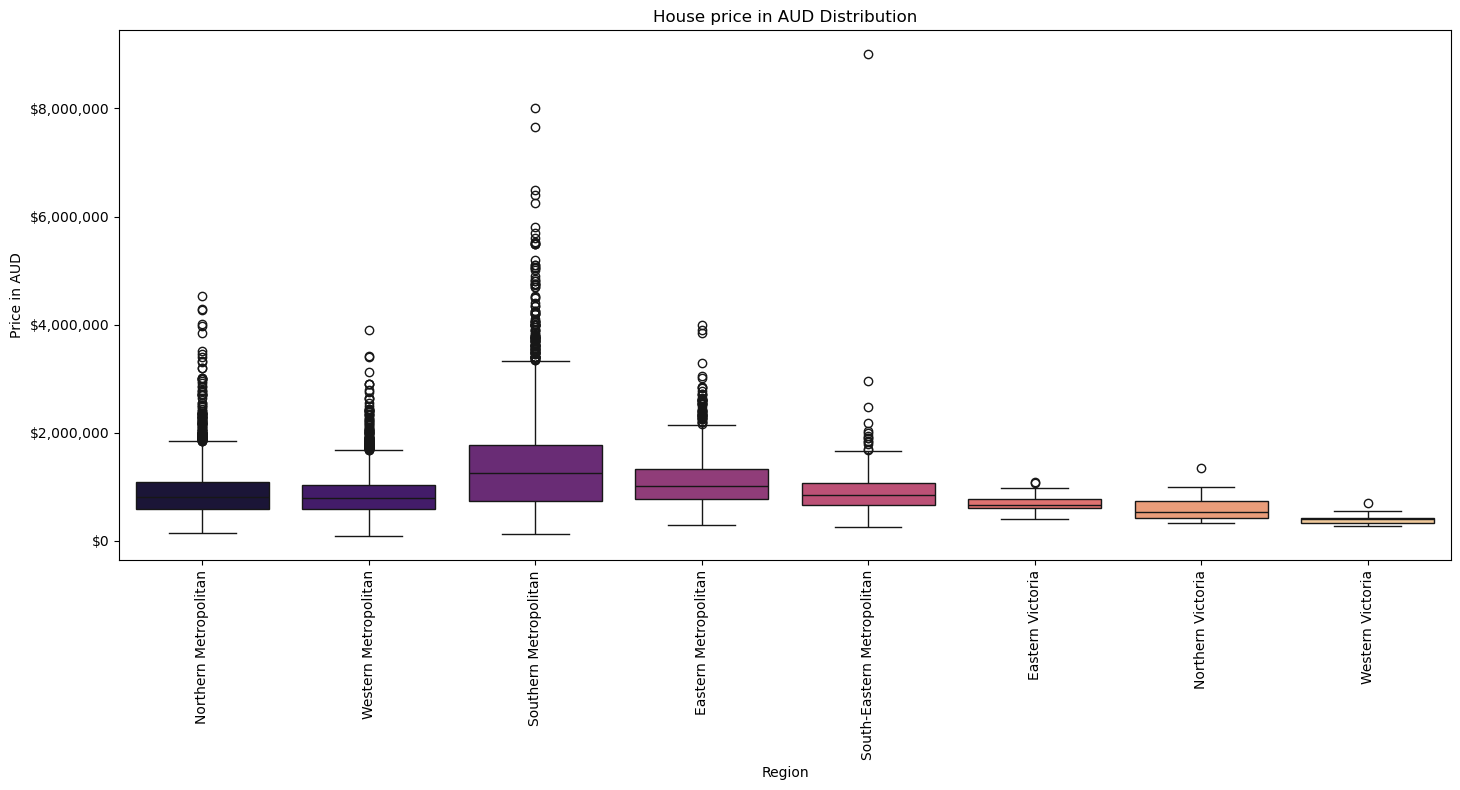

In [35]:
#after we found the distance for each region, we want to know how is the price affected by the distance

# Set figure
plt.figure(figsize=(14, 8))

#create boxplot
sns.boxplot(x='Regionname', y='Price', data=melhousingclean_df, palette='magma')

#add title and labels
plt.title('House price in AUD Distribution')
plt.xlabel('Region')
plt.ylabel('Price in AUD')
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}')) #use get current axis to display the numbers as currency

# show the plot
plt.show()

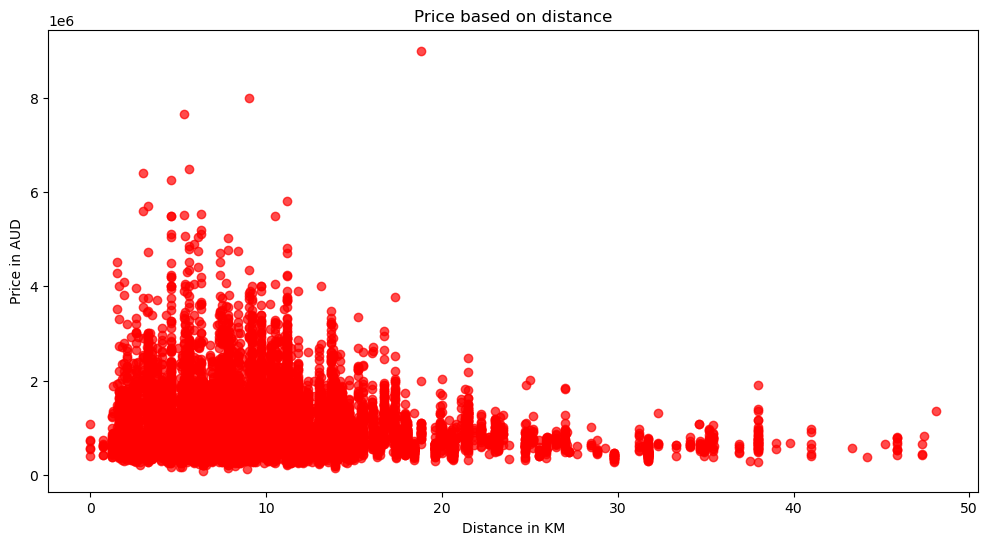

In [36]:
#to create the plot
plt.figure(figsize=(12, 6))
#to create the scatter
plt.scatter(melhousingclean_df['Distance'], melhousingclean_df['Price'], color='red', alpha=0.7)

plt.title('Price based on distance')
plt.xlabel('Distance in KM')
plt.ylabel('Price in AUD')


plt.show()

# Part 2 Analysis - Ingrid

In [37]:
melhousingdate_df = melhousingclean_df [["Date","Price","Type","Suburb"]]
replace_type = {
    'h': 'house',
    'u': 'unit',
    't': 'townhouse'
}
melhousingclean_df['Type'] = melhousingclean_df['Type'].replace(replace_type)
melhousingdate_df

,Date,Price,Type,Suburb
0,12/3/2016,1480000,h,Abbotsford
1,2/4/2016,1035000,h,Abbotsford
2,3/4/2017,1465000,h,Abbotsford
3,3/4/2017,850000,h,Abbotsford
4,6/4/2016,1600000,h,Abbotsford
...,...,...,...,...
13575,8/26/2017,1245000,h,Wheelers Hill
13576,8/26/2017,1031000,h,Williamstown
13577,8/26/2017,1170000,h,Williamstown
13578,8/26/2017,2500000,h,Williamstown


In [38]:
melhousingdatesorted_df= melhousingdate_df.sort_values(by='Date')
melhousingdatesorted_df

,Date,Price,Type,Suburb
6183,1/28/2016,813000,u,Surrey Hills
6184,1/28/2016,1205000,h,Surrey Hills
5494,10/15/2016,780000,h,Seddon
4438,10/15/2016,1010000,h,Northcote
2804,10/15/2016,1220000,t,Glen Iris
...,...,...,...,...
12499,9/9/2017,1225000,h,Flemington
12500,9/9/2017,800000,h,Footscray
12501,9/9/2017,1010000,h,Frankston
12491,9/9/2017,375000,h,Epping


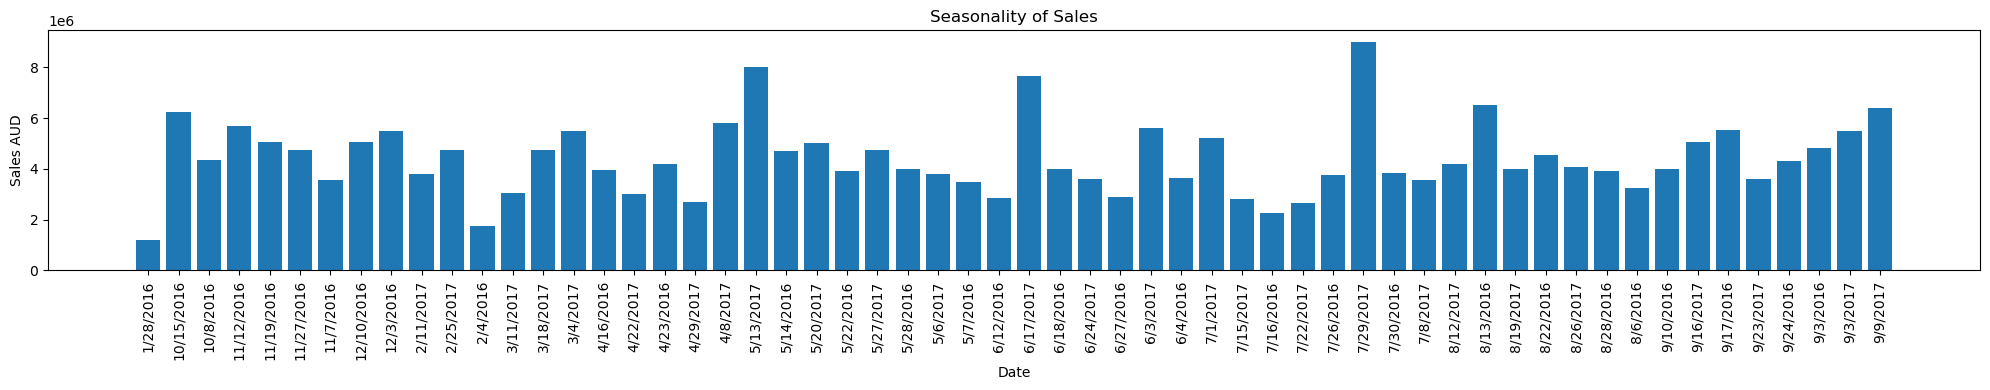

In [39]:
plt.figure(figsize=(20,4))
Date=melhousingdatesorted_df['Date']
Price=melhousingdatesorted_df['Price']
plt.bar(Date.values, Price.values, alpha=1.0, facecolor='#1f77b4', align="center")
plt.xlabel('Date')
plt.xticks (rotation ="vertical")
plt.ylabel('Sales AUD')

plt.title('Seasonality of Sales')
plt.tight_layout()
plt.show()

In [40]:
# Step 1: Convert the 'Date' column to datetime
melhousingdatesorted2_df=melhousingdatesorted_df
melhousingdatesorted2_df['Date'] = pd.to_datetime(melhousingdatesorted_df['Date'], format='%m/%d/%Y')
melhousingdatesorted2_df['Date'] 

6183    2016-01-28
6184    2016-01-28
5494    2016-10-15
4438    2016-10-15
2804    2016-10-15
           ...    
12499   2017-09-09
12500   2017-09-09
12501   2017-09-09
12491   2017-09-09
12460   2017-09-09
Name: Date, Length: 13580, dtype: datetime64[ns]

In [41]:
# Step 2: Group by Year and Month and calculate the total Price for each group
melhousingdatesorted2_df['YearMonth'] = melhousingdatesorted_df['Date'].dt.to_period('M')  

# Create a Year-Month column
total_sales_per_month = melhousingdatesorted2_df.groupby('YearMonth')['Price'].sum()  

In [42]:
# Group by Year-Month and sum the Price
# Step 3: Display the result
print(total_sales_per_month)

YearMonth
2016-01       2018000
2016-02      23612750
2016-04     316741750
2016-05     940410800
2016-06     767406240
2016-07     419818446
2016-08     768646549
2016-09    1016925100
2016-10     587002688
2016-11    1244909014
2016-12     710747009
2017-02     465623838
2017-03     773771638
2017-04     649498826
2017-05    1281517889
2017-06    1202315325
2017-07    1363108186
2017-08     999126958
2017-09    1074588793
Freq: M, Name: Price, dtype: int64


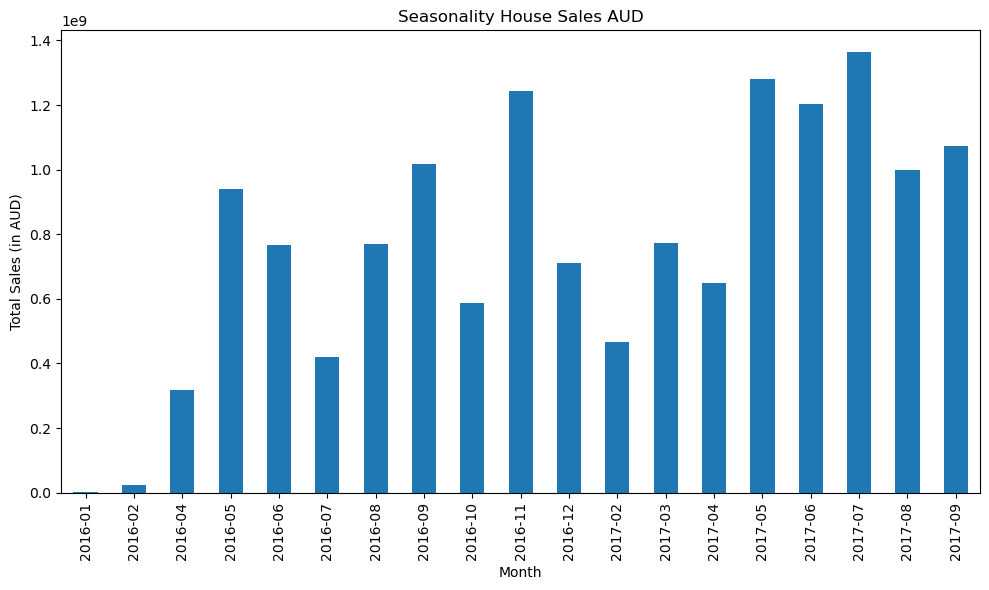

In [43]:
# Step 1: Plot the bar chart
plt.figure(figsize=(10, 6))  # Set the size of the plot
total_sales_per_month.plot(kind='bar')

# Step 2: Customize the plot
plt.title('Seasonality House Sales AUD')
plt.xlabel('Month')
plt.ylabel('Total Sales (in AUD)')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Step 3: Show the plot
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [44]:
Type_trends_df= melhousingclean_df [["Date","Price","Type"]]
Type_trends_df

,Date,Price,Type
0,12/3/2016,1480000,house
1,2/4/2016,1035000,house
2,3/4/2017,1465000,house
3,3/4/2017,850000,house
4,6/4/2016,1600000,house
...,...,...,...
13575,8/26/2017,1245000,house
13576,8/26/2017,1031000,house
13577,8/26/2017,1170000,house
13578,8/26/2017,2500000,house


In [45]:
Type_trends_h_df= Type_trends_df.query('Type=="house"')
Type_trends_h_df.head()

,Date,Price,Type
0,12/3/2016,1480000,house
1,2/4/2016,1035000,house
2,3/4/2017,1465000,house
3,3/4/2017,850000,house
4,6/4/2016,1600000,house


In [46]:
Type_trends_h_df['Date'] = pd.to_datetime(Type_trends_h_df['Date'])
Typemonthly_data_monthly_h_df = Type_trends_h_df.resample('ME', on='Date').sum()
Typemonthly_data_monthly_h_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/4204934386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Type_trends_h_df['Date'] = pd.to_datetime(Type_trends_h_df['Date'])


,Price,Type
Date,,
2016-01-31,1205000,house
2016-02-29,16876750,househousehousehousehousehousehousehousehouseh...
2016-03-31,0,0
2016-04-30,255219000,househousehousehousehousehousehousehousehouseh...
2016-05-31,744249650,househousehousehousehousehousehousehousehouseh...
2016-06-30,593158400,househousehousehousehousehousehousehousehouseh...
2016-07-31,320044446,househousehousehousehousehousehousehousehouseh...
2016-08-31,607330221,househousehousehousehousehousehousehousehouseh...
2016-09-30,793750450,househousehousehousehousehousehousehousehouseh...


In [47]:
#Typemonthly_data_monthly_h_df = Type_trends_h_df.resample('ME', on='Date').sum()
#Typemonthly_data_monthly_h_df

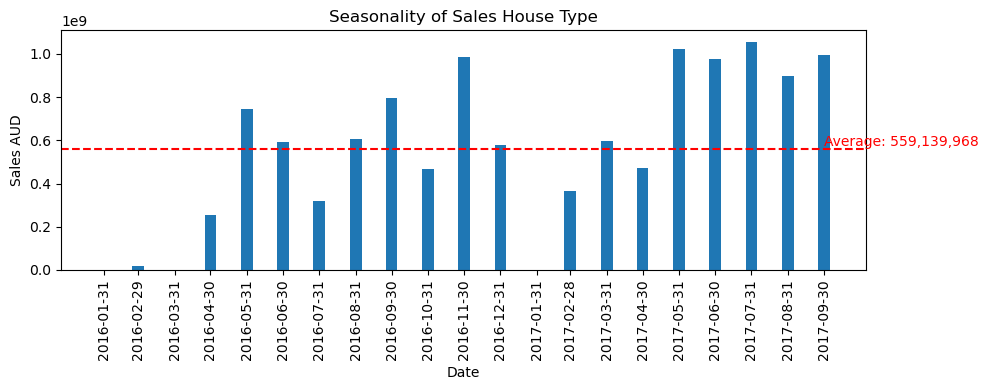

In [48]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Typemonthly_data_monthly_h_df.index
Price = Typemonthly_data_monthly_h_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Sales AUD')

plt.title('Seasonality of Sales House Type')
plt.tight_layout()

plt.show()

In [49]:
Type_trends_u_df= Type_trends_df.query('Type=="unit"')
Type_trends_u_df.head()

,Date,Price,Type
8,10/8/2016,300000,unit
10,11/12/2016,700000,unit
12,11/12/2016,750000,unit
14,5/14/2016,441000,unit
22,3/18/2017,1090000,unit


In [50]:
Typemonthly_data_monthly_u_df = Type_trends_h_df.resample('ME', on='Date').sum()
Typemonthly_data_monthly_u_df

,Price,Type
Date,,
2016-01-31,1205000,house
2016-02-29,16876750,househousehousehousehousehousehousehousehouseh...
2016-03-31,0,0
2016-04-30,255219000,househousehousehousehousehousehousehousehouseh...
2016-05-31,744249650,househousehousehousehousehousehousehousehouseh...
2016-06-30,593158400,househousehousehousehousehousehousehousehouseh...
2016-07-31,320044446,househousehousehousehousehousehousehousehouseh...
2016-08-31,607330221,househousehousehousehousehousehousehousehouseh...
2016-09-30,793750450,househousehousehousehousehousehousehousehouseh...


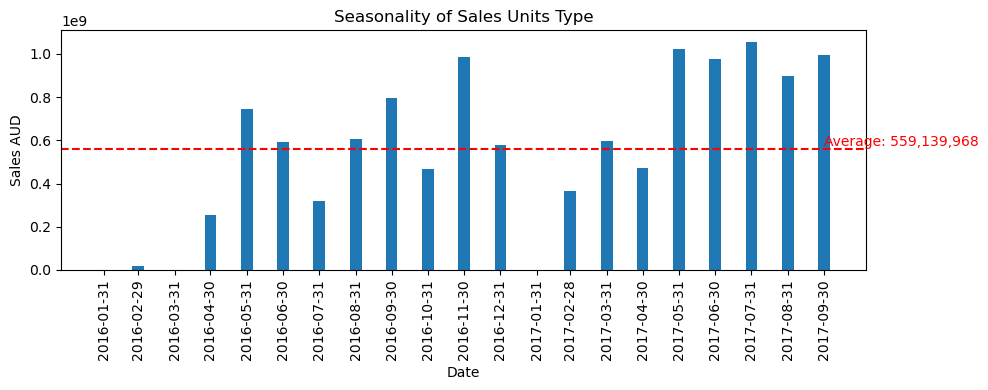

In [51]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Typemonthly_data_monthly_u_df.index
Price = Typemonthly_data_monthly_u_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Sales AUD')

plt.title('Seasonality of Sales Units Type')
plt.tight_layout()

plt.show()

In [52]:
Type_trends_t_df= Type_trends_df.query('Type=="townhouse"')
Type_trends_t_df.head()

,Date,Price,Type
21,3/18/2017,900000,townhouse
38,9/3/2016,840000,townhouse
42,3/4/2017,700000,townhouse
48,5/7/2016,450000,townhouse
56,10/15/2016,700000,townhouse


In [53]:
Typemonthly_data_monthly_t_df = Type_trends_h_df.resample('ME', on='Date').sum()
Typemonthly_data_monthly_t_df

,Price,Type
Date,,
2016-01-31,1205000,house
2016-02-29,16876750,househousehousehousehousehousehousehousehouseh...
2016-03-31,0,0
2016-04-30,255219000,househousehousehousehousehousehousehousehouseh...
2016-05-31,744249650,househousehousehousehousehousehousehousehouseh...
2016-06-30,593158400,househousehousehousehousehousehousehousehouseh...
2016-07-31,320044446,househousehousehousehousehousehousehousehouseh...
2016-08-31,607330221,househousehousehousehousehousehousehousehouseh...
2016-09-30,793750450,househousehousehousehousehousehousehousehouseh...


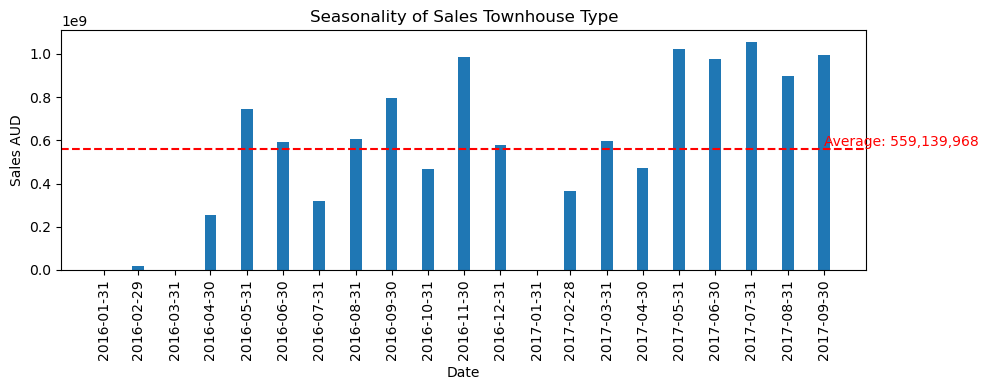

In [54]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Typemonthly_data_monthly_t_df.index
Price = Typemonthly_data_monthly_t_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Sales AUD')

plt.title('Seasonality of Sales Townhouse Type')
plt.tight_layout()

plt.show()

In [55]:
# Step 2: Group by Year and Month and calculate the total Price for each group
melhousingdatesorted2_df['YearMonth'] = melhousingdatesorted_df['Date'].dt.to_period('M')  

# Create a Year-Month column
total_avg_sales_per_month = melhousingdatesorted2_df.groupby('YearMonth')['Price'].mean()  
print(total_avg_sales_per_month)

YearMonth
2016-01    1.009000e+06
2016-02    9.081827e+05
2016-04    9.960432e+05
2016-05    1.046063e+06
2016-06    1.048369e+06
2016-07    9.412970e+05
2016-08    1.073529e+06
2016-09    1.099378e+06
2016-10    1.065341e+06
2016-11    1.117513e+06
2016-12    1.170918e+06
2017-02    1.116604e+06
2017-03    1.141256e+06
2017-04    1.029317e+06
2017-05    1.134087e+06
2017-06    1.095005e+06
2017-07    8.874402e+05
2017-08    1.197994e+06
2017-09    1.168031e+06
Freq: M, Name: Price, dtype: float64


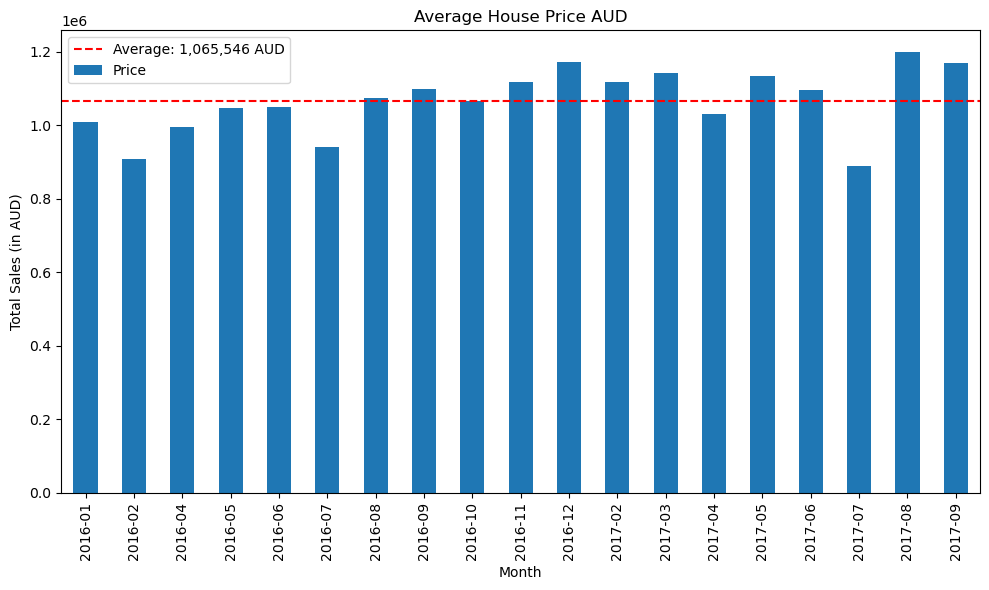

In [56]:
# Step 1: Plot the bar chart
plt.figure(figsize=(10, 6))  # Set the size of the plot
total_avg_sales_per_month.plot(kind='bar')

average_sales = total_avg_sales_per_month.mean()
plt.axhline(y=average_sales, color='red', linestyle='--', label=f'Average: {average_sales:,.0f} AUD')

# Step 2: Customize the plot
plt.title('Average House Price AUD')
plt.xlabel('Month')
plt.ylabel('Total Sales (in AUD)')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Step 3: Show the plot
plt.legend()
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [57]:
numberofrooms_trends_df= melhousingclean_df [["Date","Price","Bedroom2"]]
numberofrooms_trends_df

,Date,Price,Bedroom2
0,12/3/2016,1480000,2
1,2/4/2016,1035000,2
2,3/4/2017,1465000,3
3,3/4/2017,850000,3
4,6/4/2016,1600000,3
...,...,...,...
13575,8/26/2017,1245000,4
13576,8/26/2017,1031000,3
13577,8/26/2017,1170000,3
13578,8/26/2017,2500000,4


In [58]:
Bedroomprices_1_df= numberofrooms_trends_df.query('Bedroom2==1')
Bedroomprices_1_df.head()

,Date,Price,Bedroom2
8,10/8/2016,300000,1
14,5/14/2016,441000,1
26,8/22/2016,426000,1
28,8/22/2016,457000,1
33,7/26/2016,470000,1


In [59]:
Bedroomprices_1_df['Date'] = pd.to_datetime(Bedroomprices_1_df['Date'])
Bedroomprices1_monthly_df= Bedroomprices_1_df.resample('ME', on='Date').mean()
Bedroomprices1_monthly_df.head()

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/1295143713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_1_df['Date'] = pd.to_datetime(Bedroomprices_1_df['Date'])


,Price,Bedroom2
Date,,
2016-02-29,233000.000000,1.0
2016-03-31,NaN,NaN
2016-04-30,360576.923077,1.0
2016-05-31,445636.363636,1.0
2016-06-30,474861.111111,1.0


In [60]:
#Bedroomprices1_monthly_df= Bedroomprices_1_df.resample('ME', on='Date').mean()
#Bedroomprices1_monthly_df.head()

In [61]:
Bedroomprices1_monthly_df= Bedroomprices_1_df.resample('ME', on='Date').mean()
Bedroomprices1_monthly_df.fillna(0, inplace=True)
Bedroomprices1_monthly_df

,Price,Bedroom2
Date,,
2016-02-29,233000.000000,1.0
2016-03-31,0.000000,0.0
2016-04-30,360576.923077,1.0
2016-05-31,445636.363636,1.0
2016-06-30,474861.111111,1.0
2016-07-31,430533.333333,1.0
2016-08-31,449900.000000,1.0
2016-09-30,440050.000000,1.0
2016-10-31,422567.647059,1.0


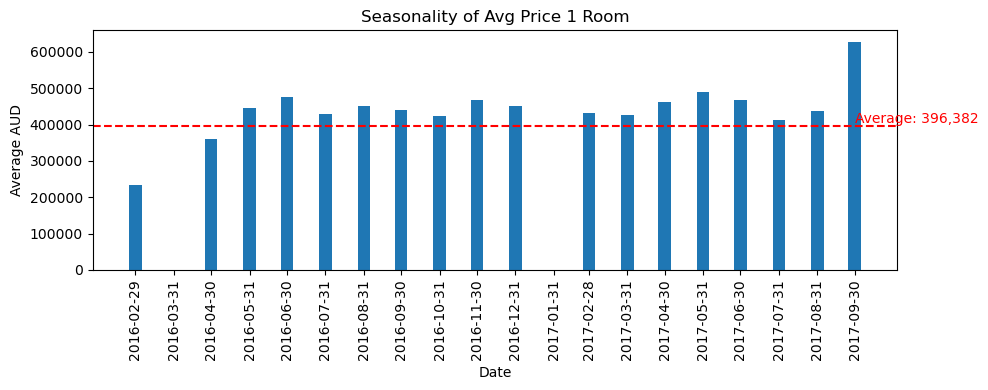

In [62]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices1_monthly_df.index
Price = Bedroomprices1_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 1 Room')
plt.tight_layout()

plt.show()

In [63]:
Bedroomprices_2_df= numberofrooms_trends_df.query('Bedroom2==2')
Bedroomprices_2_df.head()

,Date,Price,Bedroom2
0,12/3/2016,1480000,2
1,2/4/2016,1035000,2
5,5/7/2016,941000,2
7,10/8/2016,1636000,2
10,11/12/2016,700000,2


In [64]:
Bedroomprices_2_df['Date'] = pd.to_datetime(Type_trends_h_df['Date'])
Bedroomprices2_monthly_df= Bedroomprices_2_df.resample('ME', on='Date').mean()
Bedroomprices2_monthly_df.fillna(0, inplace=True)
Bedroomprices2_monthly_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3864654596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_2_df['Date'] = pd.to_datetime(Type_trends_h_df['Date'])


,Price,Bedroom2
Date,,
2016-02-29,9.042500e+05,2.0
2016-03-31,0.000000e+00,0.0
2016-04-30,9.781058e+05,2.0
2016-05-31,9.358840e+05,2.0
2016-06-30,9.856200e+05,2.0
2016-07-31,8.815554e+05,2.0
2016-08-31,1.066957e+06,2.0
2016-09-30,1.046014e+06,2.0
2016-10-31,1.036172e+06,2.0


In [65]:
#Bedroomprices2_monthly_df= Bedroomprices_2_df.resample('ME', on='Date').mean()
#Bedroomprices2_monthly_df.fillna(0, inplace=True)
#Bedroomprices2_monthly_df
#Bedroomprices2_monthlyf_df['Price'] = Bedroomprices2_monthly_df['Price'].apply(lambda x: f'{x:,.0f}')

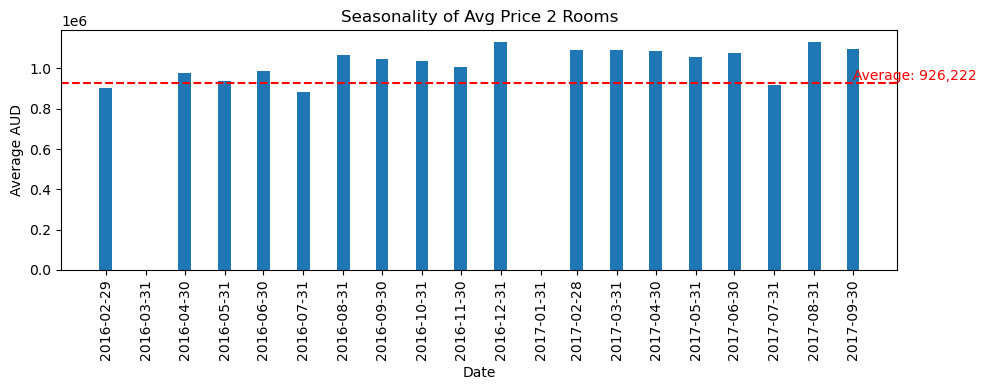

In [66]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices2_monthly_df.index
Price = Bedroomprices2_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 2 Rooms')
plt.tight_layout()

plt.show()

In [67]:
Bedroomprices_3_df= numberofrooms_trends_df.query('Bedroom2==3')

Bedroomprices_3_df.head()

,Date,Price,Bedroom2
2,3/4/2017,1465000,3
3,3/4/2017,850000,3
4,6/4/2016,1600000,3
9,10/8/2016,1097000,3
11,11/12/2016,1350000,3


In [68]:
Bedroomprices_3_df['Date'] = pd.to_datetime(Bedroomprices_3_df['Date'])
Bedroomprices3_monthly_df= Bedroomprices_3_df.resample('ME', on='Date').mean()
Bedroomprices3_monthly_df.fillna(0, inplace=True)
Bedroomprices3_monthly_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/2236063361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_3_df['Date'] = pd.to_datetime(Bedroomprices_3_df['Date'])


,Price,Bedroom2
Date,,
2016-01-31,1.205000e+06,3.0
2016-02-29,1.067054e+06,3.0
2016-03-31,0.000000e+00,0.0
2016-04-30,1.042850e+06,3.0
2016-05-31,1.085152e+06,3.0
2016-06-30,1.110174e+06,3.0
2016-07-31,1.075855e+06,3.0
2016-08-31,1.123935e+06,3.0
2016-09-30,1.180886e+06,3.0


In [69]:

#Bedroomprices3_monthly_df= Bedroomprices_3_df.resample('ME', on='Date').mean()
#Bedroomprices3_monthly_df.fillna(0, inplace=True)
#Bedroomprices3_monthly_df

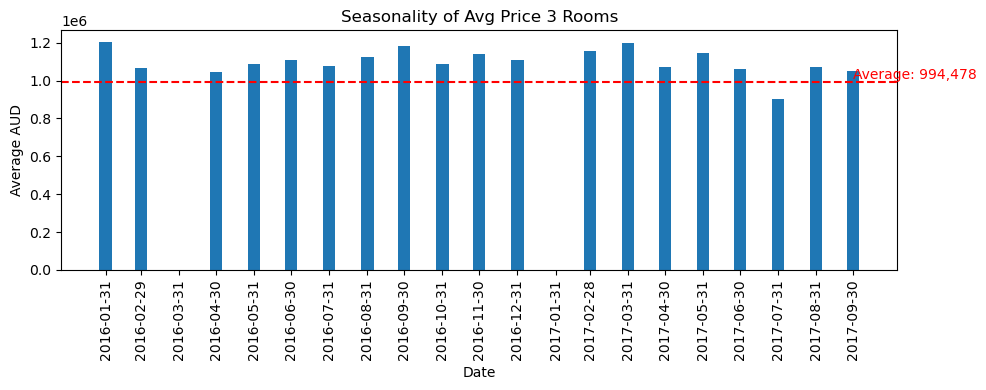

In [70]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices3_monthly_df.index
Price = Bedroomprices3_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 3 Rooms')
plt.tight_layout()

plt.show()

In [71]:
Bedroomprices_4_df= numberofrooms_trends_df.query('Bedroom2==4')
Bedroomprices_4_df.head()

,Date,Price,Bedroom2
6,5/7/2016,1876000,4
20,3/18/2017,1330000,4
30,9/24/2016,1542000,4
74,9/24/2016,978000,4
76,11/27/2016,765000,4


In [72]:
Bedroomprices_4_df['Date'] = pd.to_datetime(Bedroomprices_4_df['Date'])
Bedroomprices4_monthly_df= Bedroomprices_4_df.resample('ME', on='Date').mean()
Bedroomprices4_monthly_df.fillna(0, inplace=True)
Bedroomprices4_monthly_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/888563626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_4_df['Date'] = pd.to_datetime(Bedroomprices_4_df['Date'])


,Price,Bedroom2
Date,,
2016-02-29,8.830000e+05,4.0
2016-03-31,0.000000e+00,0.0
2016-04-30,1.493453e+06,4.0
2016-05-31,1.544042e+06,4.0
2016-06-30,1.489619e+06,4.0
2016-07-31,1.250465e+06,4.0
2016-08-31,1.674817e+06,4.0
2016-09-30,1.544586e+06,4.0
2016-10-31,1.641904e+06,4.0


In [73]:
#Bedroomprices4_monthly_df= Bedroomprices_4_df.resample('ME', on='Date').mean()
#Bedroomprices4_monthly_df.fillna(0, inplace=True)
#Bedroomprices4_monthly_df

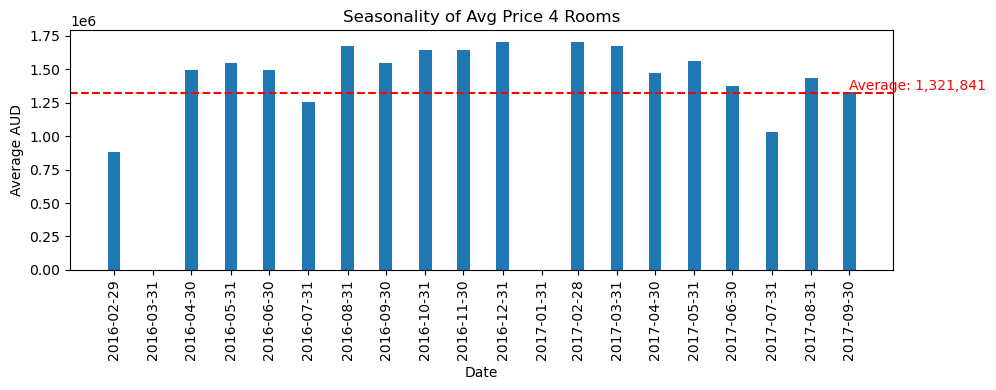

In [74]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices4_monthly_df.index
Price = Bedroomprices4_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 4 Rooms')
plt.tight_layout()

plt.show()

In [75]:
Bedroomprices_5_df= numberofrooms_trends_df.query('Bedroom2==5')
Bedroomprices_5_df.head()

,Date,Price,Bedroom2
63,9/17/2016,773000,5
93,12/10/2016,2100000,5
124,6/12/2016,2840000,5
142,12/3/2016,1525000,5
186,9/3/2016,1085000,5


In [76]:
Bedroomprices_5_df['Date'] = pd.to_datetime(Bedroomprices_5_df['Date'])
Bedroomprices5_monthly_df= Bedroomprices_5_df.resample('ME', on='Date').mean()
Bedroomprices5_monthly_df.fillna(0,inplace=True)
Bedroomprices5_monthly_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/1162660047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_5_df['Date'] = pd.to_datetime(Bedroomprices_5_df['Date'])


,Price,Bedroom2
Date,,
2016-04-30,1.483583e+06,5.0
2016-05-31,2.089042e+06,5.0
2016-06-30,1.883333e+06,5.0
2016-07-31,1.467000e+06,5.0
2016-08-31,2.093909e+06,5.0
2016-09-30,1.952290e+06,5.0
2016-10-31,2.044190e+06,5.0
2016-11-30,2.233269e+06,5.0
2016-12-31,2.355943e+06,5.0


In [77]:
#Bedroomprices5_monthly_df= Bedroomprices_5_df.resample('ME', on='Date').mean()
#Bedroomprices5_monthly_df.fillna(0,inplace=True)
#Bedroomprices5_monthly_df

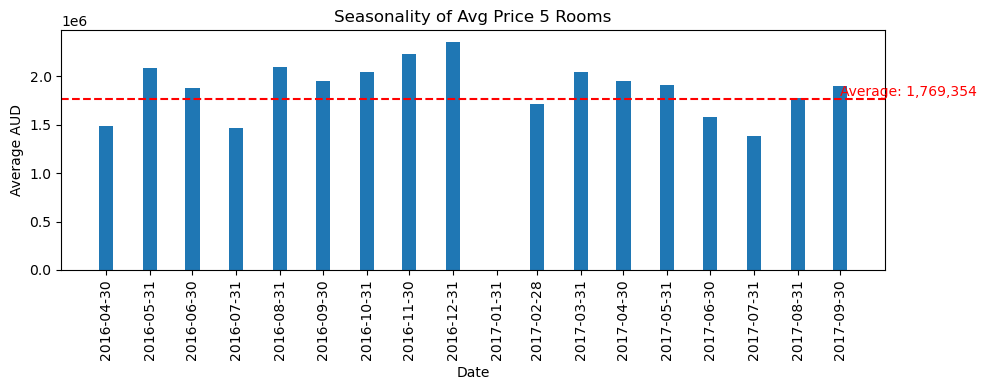

In [78]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices5_monthly_df.index
Price = Bedroomprices5_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 5 Rooms')
plt.tight_layout()

plt.show()

In [79]:
Bedroomprices_6_df= numberofrooms_trends_df.query('Bedroom2==6')
Bedroomprices_6_df.head()

,Date,Price,Bedroom2
47,5/7/2016,725000,6
292,6/4/2016,2425000,6
392,8/22/2016,2752000,6
515,12/3/2016,4000000,6
663,5/22/2016,1900000,6


In [80]:
Bedroomprices_6_df['Date'] = pd.to_datetime(Bedroomprices_6_df['Date'])
Bedroomprices6_monthly_df= Bedroomprices_6_df.resample('ME', on='Date').mean()
Bedroomprices6_monthly_df.fillna(0, inplace=True)
Bedroomprices6_monthly_df

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/1069263713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bedroomprices_6_df['Date'] = pd.to_datetime(Bedroomprices_6_df['Date'])


,Price,Bedroom2
Date,,
2016-05-31,1.556250e+06,6.0
2016-06-30,2.068750e+06,6.0
2016-07-31,1.440500e+06,6.0
2016-08-31,4.626000e+06,6.0
2016-09-30,1.666000e+06,6.0
2016-10-31,0.000000e+00,0.0
2016-11-30,2.125000e+06,6.0
2016-12-31,2.268000e+06,6.0
2017-01-31,0.000000e+00,0.0


In [81]:
#Bedroomprices6_monthly_df= Bedroomprices_6_df.resample('ME', on='Date').mean()
#Bedroomprices6_monthly_df.fillna(0, inplace=True)
#Bedroomprices6_monthly_df

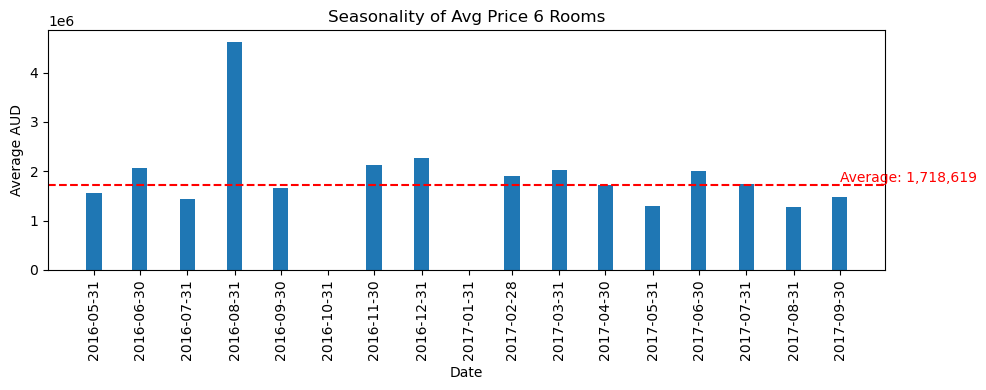

In [82]:
plt.figure(figsize=(10,4))

# Use the index as Date since 'Date' is now the index after resampling
Date = Bedroomprices6_monthly_df.index
Price = Bedroomprices6_monthly_df['Price']

# Bar plot with Date as the x-axis and Price as the y-axis
plt.bar(Date, Price, alpha=1.0, width=10, facecolor='#1f77b4', align="center")
average_price = Price.mean()
plt.axhline(y=average_price, color='red', linestyle='--', label=f'Average: {average_price:,.0f}') #label=f'Average: {round(average_price, 2)}')
plt.text(Date[-1], average_price, f'Average: {average_price:,.0f}', color='red', va='bottom') #f'Average: {round(average_price, 2)}'

plt.xlabel('Date')
plt.xticks (Date[::1],rotation ="vertical")
plt.ylabel('Average AUD')

plt.title('Seasonality of Avg Price 6 Rooms')
plt.tight_layout()

plt.show()

In [83]:
Bedroom_sales_year = melhousingclean_df.groupby(['Year', 'Bedroom2']).size().reset_index(name='Count')
Bedroom_sales_year

,Year,Bedroom2,Count
0,2016.0,0,10
1,2016.0,1,380
2,2016.0,2,2065
3,2016.0,3,2621
4,2016.0,4,1010
5,2016.0,5,219
6,2016.0,6,20
7,2017.0,0,6
8,2017.0,1,311
9,2017.0,2,1672


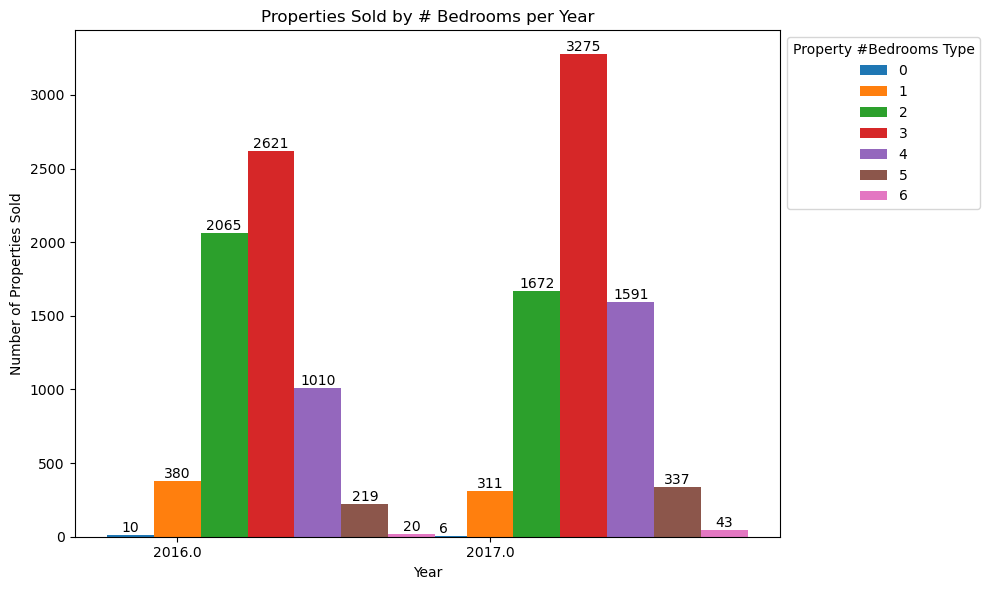

In [84]:
# Step 1: Group the data by 'Year' and 'Type' and count occurrences
#house_per_year = melhousingclean_df.groupby(['Year', 'Type']).size().reset_index(name='Count')

plt.figure(figsize=(10, 6))

Sales_Roomtypes = Bedroom_sales_year['Bedroom2'].unique()
years = Bedroom_sales_year['Year'].unique()

bar_width = 0.15
positions = list(range(len(years)))

for i, Sales_Roomtypes in enumerate(Sales_Roomtypes):
    subset = Bedroom_sales_year[Bedroom_sales_year['Bedroom2'] == Sales_Roomtypes]
    bars = plt.bar([p + i * bar_width for p in positions], subset['Count'], width=bar_width, label=Sales_Roomtypes)
    
    # Step 3: Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Number of Properties Sold')
plt.title('Properties Sold by # Bedrooms per Year')
plt.xticks([p + bar_width for p in positions], years)
plt.legend(title='Property #Bedrooms Type', loc='upper left', bbox_to_anchor=(1, 1))

# Display the chart
plt.tight_layout()
plt.show()

In [85]:
# Group by 'Year' and 'number of rooms' (replace with actual column names if different)
avg_price_per_year = melhousingclean_df.groupby(['Year', 'Bedroom2'])['Price'].mean().reset_index()

# Rename the columns for clarity
avg_price_per_year.columns = ['Year', 'Rooms', 'Average_Price']

# Display the resulting DataFrame
print(avg_price_per_year)

      Year  Rooms  Average_Price
0   2016.0      0   1.039200e+06
1   2016.0      1   4.454258e+05
2   2016.0      2   7.740983e+05
3   2016.0      3   1.115431e+06
4   2016.0      4   1.575171e+06
5   2016.0      5   2.038360e+06
6   2016.0      6   2.194450e+06
7   2017.0      0   1.015250e+06
8   2017.0      1   4.495510e+05
9   2017.0      2   8.044380e+05
10  2017.0      3   1.056142e+06
11  2017.0      4   1.374188e+06
12  2017.0      5   1.734238e+06
13  2017.0      6   1.663407e+06


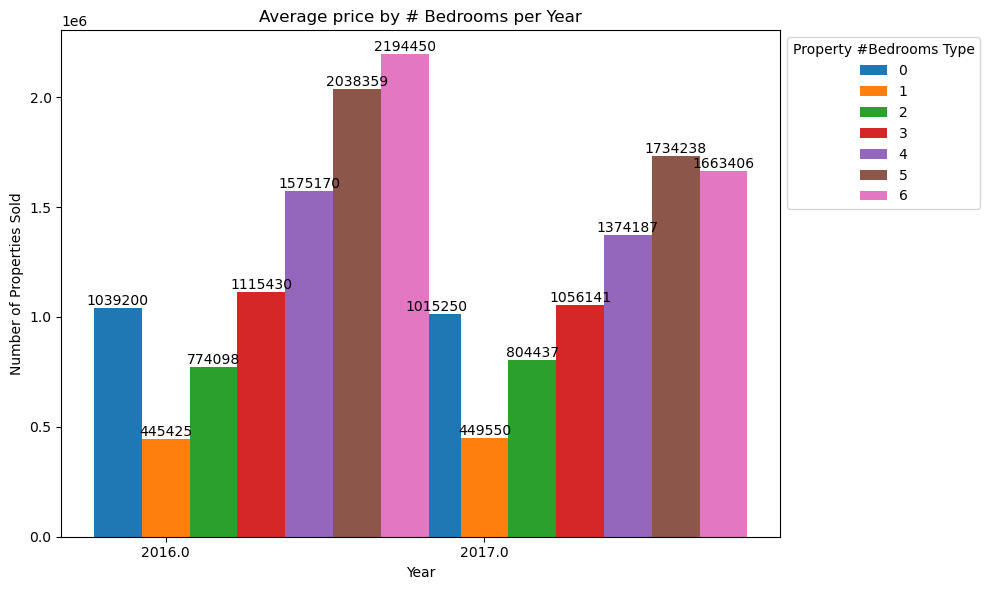

In [86]:
# Step 1: Group the data by 'Year' and 'Type' and count occurrences

plt.figure(figsize=(10, 6))

Average_price_Roomtypes = avg_price_per_year['Rooms'].unique()
Year = avg_price_per_year['Year'].unique()

bar_width = 0.15
positions = list(range(len(years)))

for i, Average_price_Roomtypes in enumerate(Average_price_Roomtypes):
    subset = avg_price_per_year[avg_price_per_year['Rooms'] == Average_price_Roomtypes]
    bars = plt.bar([p + i * bar_width for p in positions], subset['Average_Price'], width=bar_width, label=Average_price_Roomtypes)
    
    # Step 3: Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Number of Properties Sold')
plt.title('Average price by # Bedrooms per Year')
plt.xticks([p + bar_width for p in positions], years)
plt.legend(title='Property #Bedrooms Type', loc='upper left', bbox_to_anchor=(1, 1))

# Display the chart
plt.tight_layout()
plt.show()

In [87]:
filtered_data = avg_price_per_year[avg_price_per_year['Year'].isin([2016, 2017])]
filtered_data

,Year,Rooms,Average_Price
0,2016.0,0,1.039200e+06
1,2016.0,1,4.454258e+05
2,2016.0,2,7.740983e+05
3,2016.0,3,1.115431e+06
4,2016.0,4,1.575171e+06
5,2016.0,5,2.038360e+06
6,2016.0,6,2.194450e+06
7,2017.0,0,1.015250e+06
8,2017.0,1,4.495510e+05
9,2017.0,2,8.044380e+05


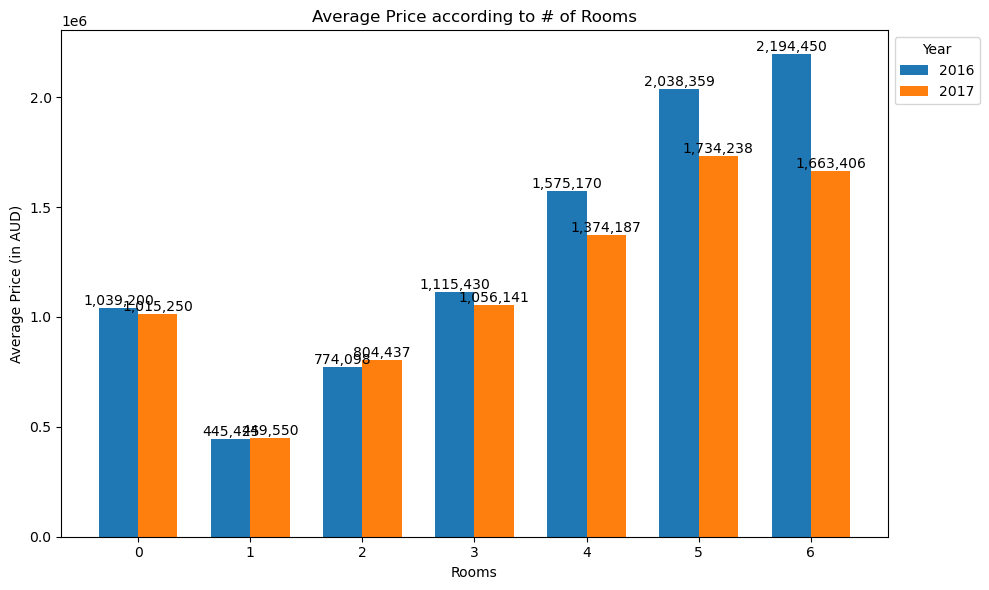

In [88]:
plt.figure(figsize=(10, 6))

years = [2016, 2017]  
Roomtypes = filtered_data['Rooms'].unique()  # Get the unique room numbers

bar_width = 0.35  # Adjust the width of the bars
positions = list(range(len(Roomtypes)))  # Set the positions for the rooms

# Step 3: Loop through the years and plot bars for each year
for i, year in enumerate(years):
    subset = filtered_data[filtered_data['Year'] == year]
    bars = plt.bar([p + i * bar_width for p in positions], subset['Average_Price'], width=bar_width, label=year)
    
    # Step 4: Add average prices on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')

# Adding labels and title
plt.xlabel('Rooms')
plt.ylabel('Average Price (in AUD)')
plt.title('Average Price according to # of Rooms')
plt.xticks([p + bar_width / 2 for p in positions], Roomtypes)  # Center the labels for rooms
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))

# Step 5: Display the chart
plt.tight_layout()
plt.show()

In [89]:
mat_plot_3= melhousingclean_df.hvplot.points(
    "Long", 
    "Lat",
    geo=True,
    tiles="OSM",
    frame_width=700,
    frame_height=500,
    size="price",
    scale=0.01,
    color="Regionname" 
)
mat_plot_3

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Long,Lat]   (Regionname)

In [90]:
mat_plot_3= melhousingclean_df.hvplot.points(
    "Long", 
    "Lat",
    geo=True,
    tiles="OSM",
    frame_width=700,
    frame_height=500,
    size="price",
    scale=0.01,
    color="Type" 
)
mat_plot_3

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Long,Lat]   (Type)

In [91]:
#creating Ranges for #rooms to be mapped

# Define the rooms bins and corresponding labels
bins = [0, 2, 3, 4,5, float('inf')]  # Rooms ranges
labels = [ '0-2 Rooms', '3 Rooms', '4 Rooms' ,'5 Rooms','>5 Rooms']  # Labels for each range

# Create a new column 'Price_Range' based on the 'Price' column
melhousingclean_df['Rooms_Range'] = pd.cut(melhousingclean_df['Bedroom2'], bins=bins, labels=labels, right=False)

# Display the updated DataFrame
print(melhousingclean_df)

              Suburb           Address  Rooms   Type    Price Method  \
0         Abbotsford      85 Turner St      2  house  1480000      S   
1         Abbotsford   25 Bloomburg St      2  house  1035000      S   
2         Abbotsford      5 Charles St      3  house  1465000     SP   
3         Abbotsford  40 Federation La      3  house   850000     PI   
4         Abbotsford       55a Park St      4  house  1600000     VB   
...              ...               ...    ...    ...      ...    ...   
13575  Wheelers Hill      12 Strada Cr      4  house  1245000      S   
13576   Williamstown     77 Merrett Dr      3  house  1031000     SP   
13577   Williamstown       83 Power St      3  house  1170000      S   
13578   Williamstown      96 Verdon St      4  house  2500000     PI   
13579     Yarraville        6 Agnes St      4  house  1285000     SP   

      PropertyAgent       Date  Distance  Postcode  ...  Bathroom  Car  \
0            Biggin  12/3/2016       2.5      3067  ...      

In [92]:
mat_plot_3= melhousingclean_df.hvplot.points(
    "Long", 
    "Lat",
    geo=True,
    tiles="OSM",
    frame_width=700,
    frame_height=500,
    size="price",
    scale=0.01,
    color="Rooms_Range" 
)
mat_plot_3

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Long,Lat]   (Rooms_Range)

In [93]:
room_counts=  melhousingclean_df['Bedroom2'].value_counts()
print(room_counts)

Bedroom2
3     5896
2     3737
4     2601
1      691
5      556
6       63
0       16
7       10
8        5
9        3
20       1
10       1
Name: count, dtype: int64


In [94]:
#creating Ranges for prices to be mapped

# Define the price bins and corresponding labels
bins = [0, 400000, 600000, 800000,1000000,1500000,2000000, float('inf')]  # Price ranges
labels = [ '<400K', '<600K', '<800K' ,'<1MM','<1.5MM','<2MM','>2MM']  # Labels for each range

# Create a new column 'Price_Range' based on the 'Price' column
melhousingclean_df['Price_Range'] = pd.cut(melhousingclean_df['Price'], bins=bins, labels=labels, right=False)

# Display the updated DataFrame
print(melhousingclean_df)

              Suburb           Address  Rooms   Type    Price Method  \
0         Abbotsford      85 Turner St      2  house  1480000      S   
1         Abbotsford   25 Bloomburg St      2  house  1035000      S   
2         Abbotsford      5 Charles St      3  house  1465000     SP   
3         Abbotsford  40 Federation La      3  house   850000     PI   
4         Abbotsford       55a Park St      4  house  1600000     VB   
...              ...               ...    ...    ...      ...    ...   
13575  Wheelers Hill      12 Strada Cr      4  house  1245000      S   
13576   Williamstown     77 Merrett Dr      3  house  1031000     SP   
13577   Williamstown       83 Power St      3  house  1170000      S   
13578   Williamstown      96 Verdon St      4  house  2500000     PI   
13579     Yarraville        6 Agnes St      4  house  1285000     SP   

      PropertyAgent       Date  Distance  Postcode  ...  Car  Landsize  \
0            Biggin  12/3/2016       2.5      3067  ...  1.0 

In [95]:
mat_plot_3= melhousingclean_df.hvplot.points(
    "Long", 
    "Lat",
    geo=True,
    tiles="OSM",
    frame_width=700,
    frame_height=500,
    size="price",
    scale=0.01,
    color="Price_Range" 
)
mat_plot_3

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Long,Lat]   (Price_Range)

In [96]:
Price_range_counts=  melhousingclean_df['Price_Range'].value_counts()
print(Price_range_counts)

Price_Range
<1.5MM    3302
<800K     2712
<1MM      2370
<600K     2042
<2MM      1476
>2MM      1062
<400K      616
Name: count, dtype: int64


/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/3541428967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bedroom2', y='Price', data=melhousingclean_df, palette='coolwarm' )


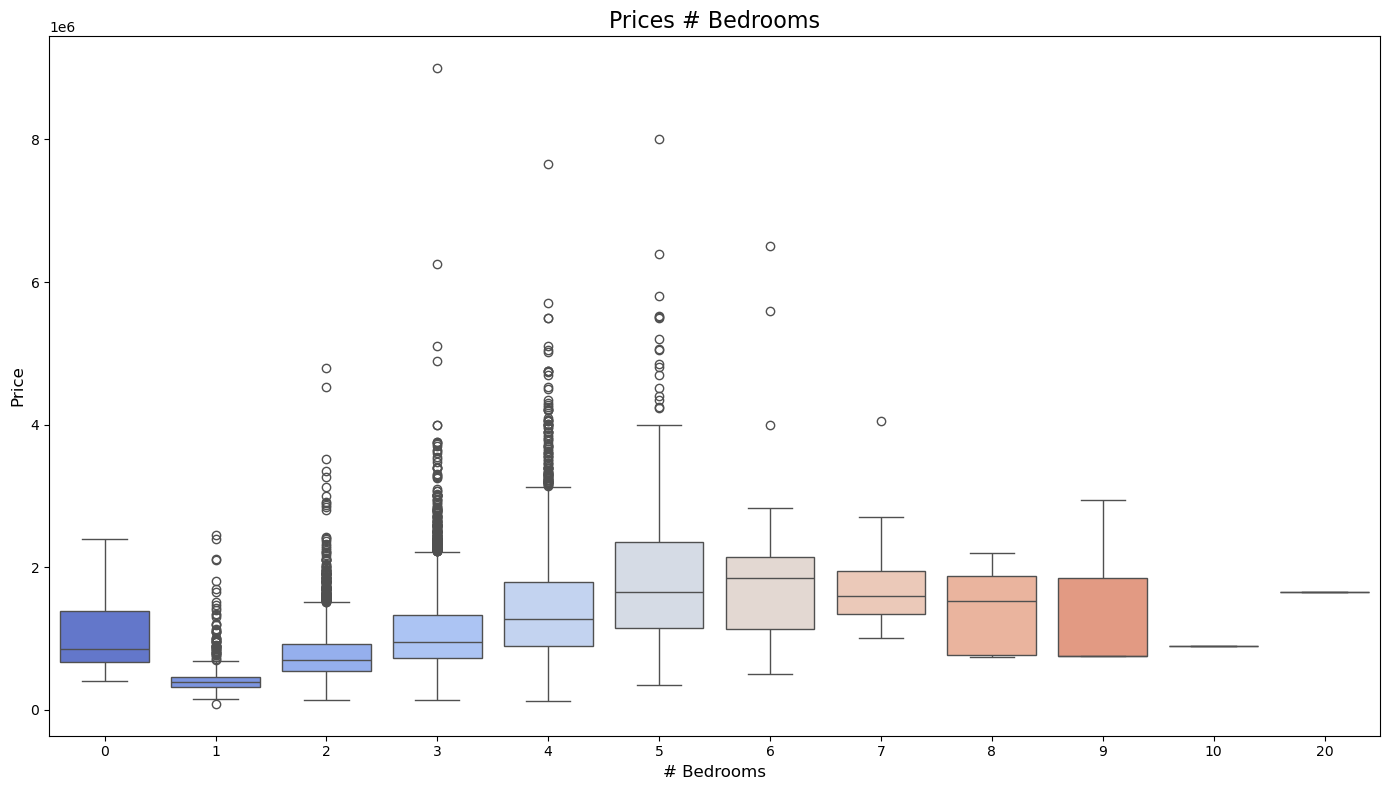

In [97]:
plt.figure(figsize=(14, 8))

sns.boxplot(x='Bedroom2', y='Price', data=melhousingclean_df, palette='coolwarm' )

plt.title('Prices # Bedrooms', fontsize=16)
plt.xlabel('# Bedrooms', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=0) 
plt.tight_layout()  

plt.show()

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/149398794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bathroom', y='Price', data=melhousingclean_df, palette='coolwarm' )


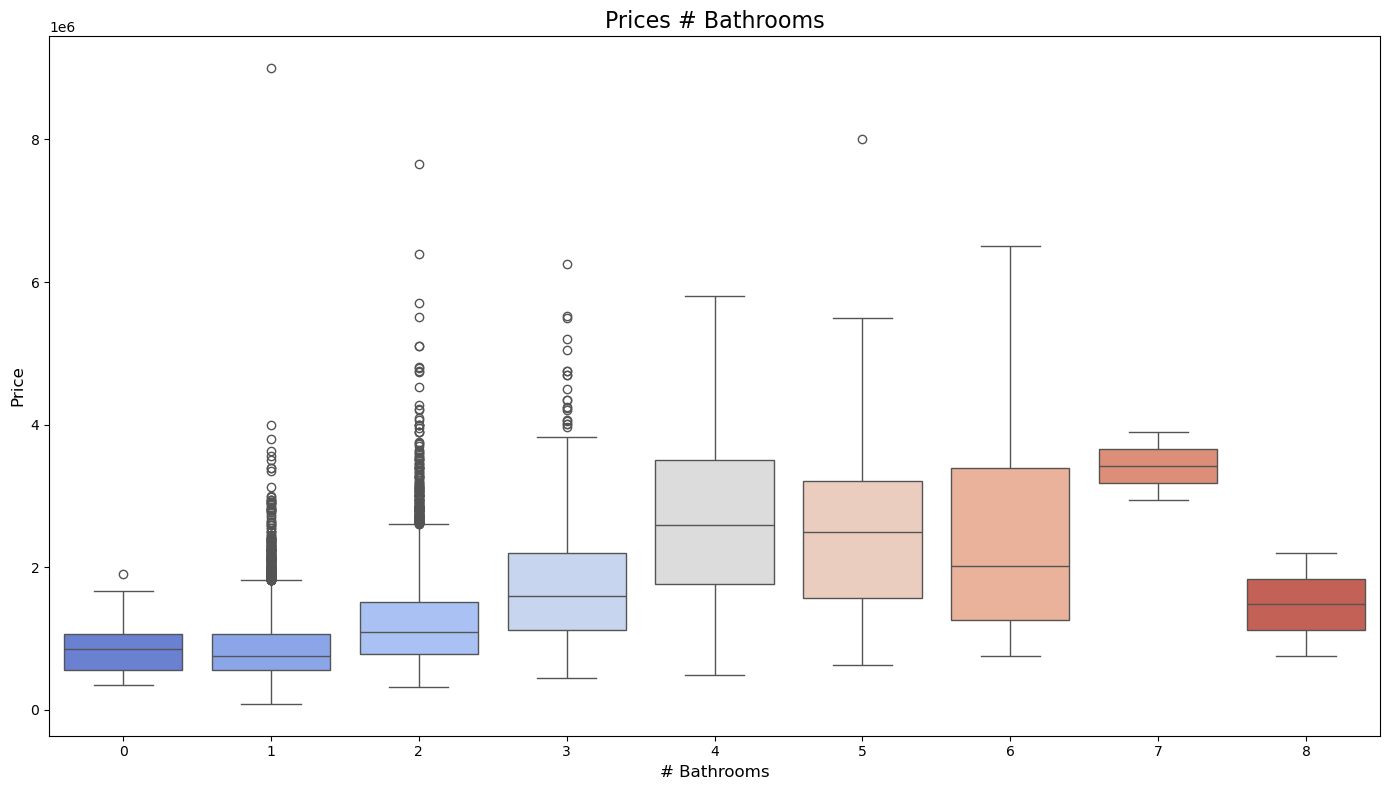

In [98]:
plt.figure(figsize=(14, 8))

sns.boxplot(x='Bathroom', y='Price', data=melhousingclean_df, palette='coolwarm' )

plt.title('Prices # Bathrooms', fontsize=16)
plt.xlabel('# Bathrooms', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=0) 
plt.tight_layout()  

plt.show()

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/162668599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Price', data=melhousingclean_df, palette='coolwarm' )


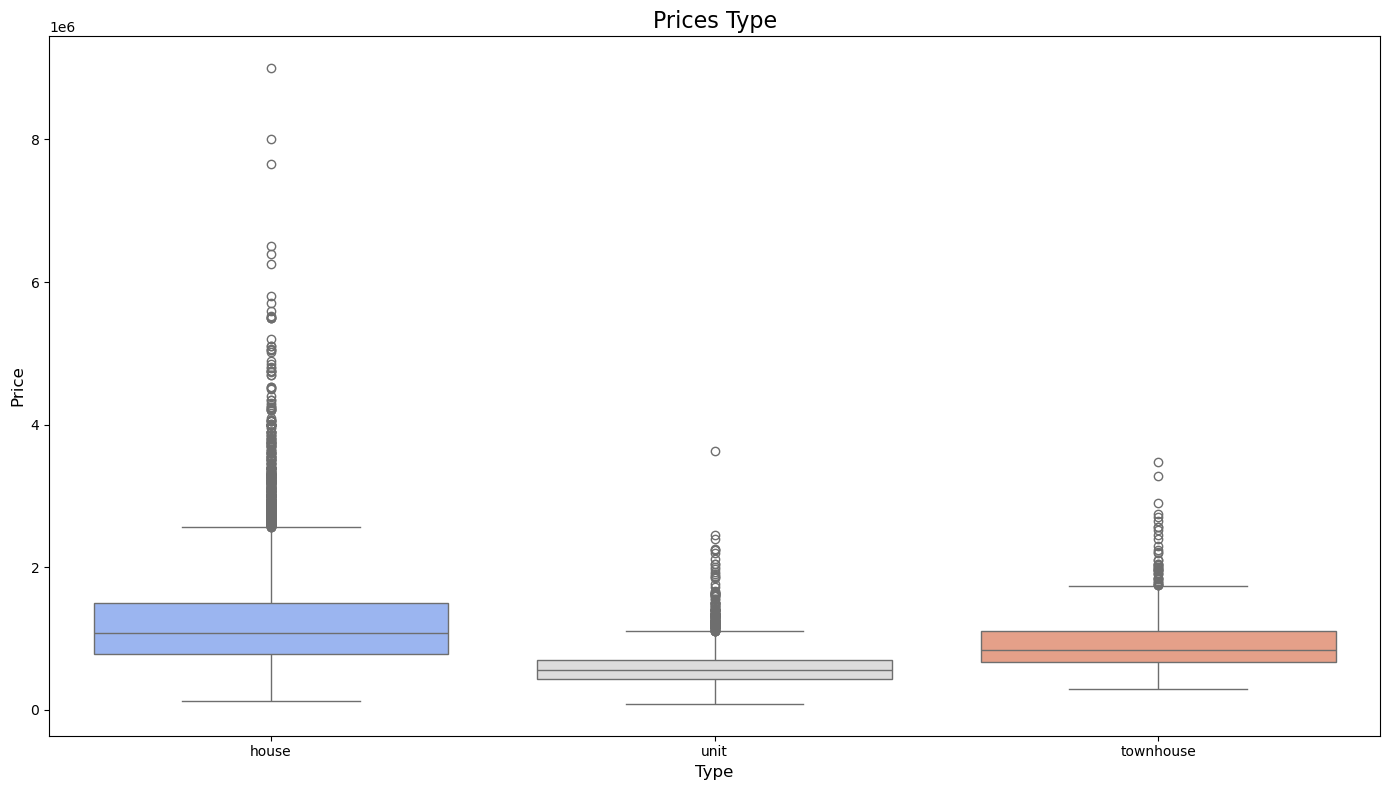

In [99]:
plt.figure(figsize=(14, 8))

sns.boxplot(x='Type', y='Price', data=melhousingclean_df, palette='coolwarm' )

plt.title('Prices Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=0) 
plt.tight_layout()  

plt.show()

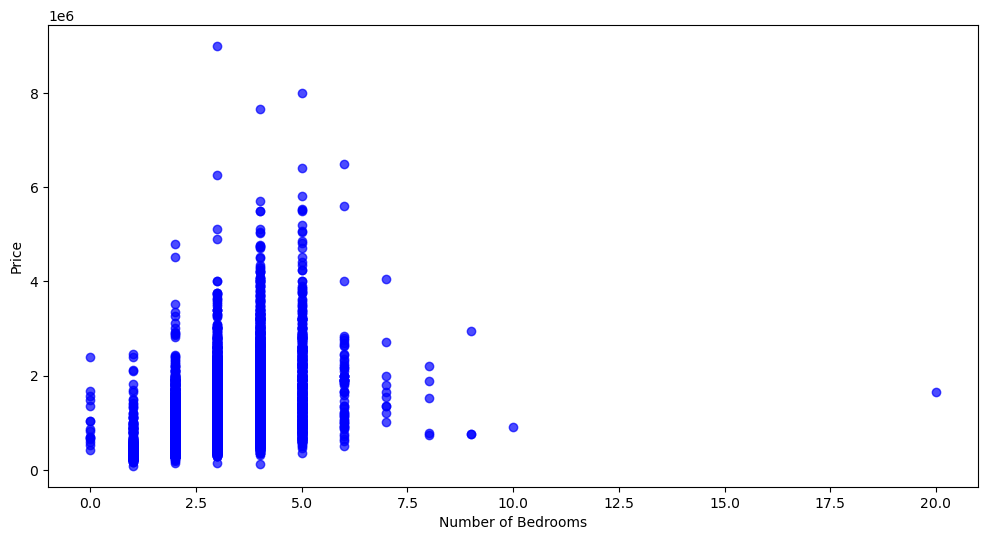

In [100]:
plt.figure (figsize=(12,6))

plt.scatter(melhousingclean_df['Bedroom2'],melhousingclean_df['Price'],color='blue',alpha=0.7)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

In [101]:
correlation = melhousingclean_df['Bedroom2'].corr(melhousingclean_df['Price'])
print(f"The correlation between Number of Bedrooms and Price: {correlation:.2f}")

The correlation between Number of Bedrooms and Price: 0.48


The r-squared is: 0.22652938522037233


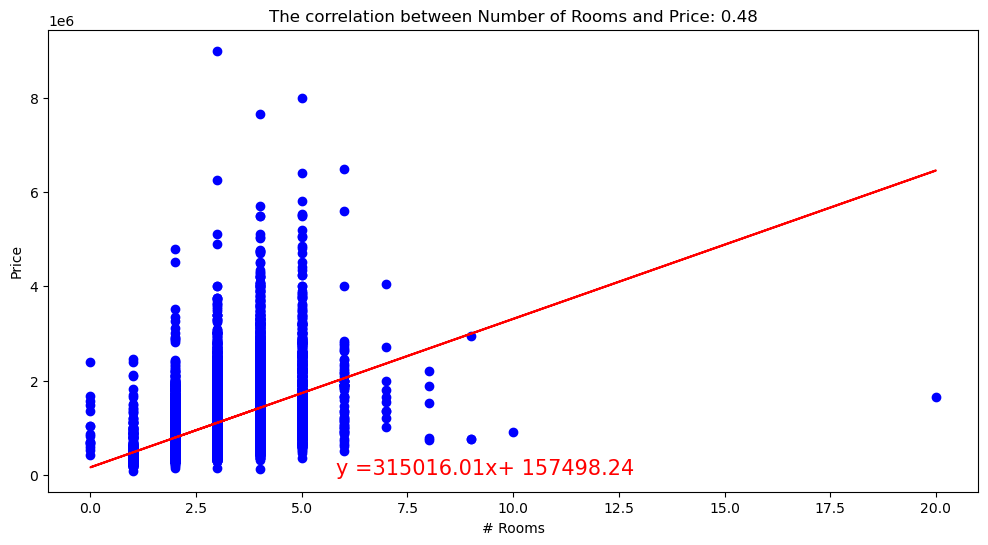

In [102]:
#linear regression model
slope, intercept, r_value, p_value, std_err = stats.linregress(melhousingclean_df['Bedroom2'], melhousingclean_df['Price'])

#to create the plot
x_values = melhousingclean_df['Bedroom2']
y_values = slope * x_values + intercept
line_eq= "y ="+ str(round(slope,2)) + "x+ " + str(round(intercept,2))

plt.figure(figsize=(12, 6))
plt.scatter(melhousingclean_df['Bedroom2'], melhousingclean_df['Price'], color='blue')
plt.plot(x_values, y_values, color='red')
plt.annotate(line_eq,(5.8,0.8),fontsize=15,color="red")
plt.title(f"The correlation between Number of Rooms and Price: {correlation:.2f}")
plt.xlabel('# Rooms')
plt.ylabel('Price')
print(f"The r-squared is: {r_value**2}")

plt.show()

In [103]:
correlationbath = melhousingclean_df['Bathroom'].corr(melhousingclean_df['Price'])
print(f"The correlation between Number of Bedrooms and Price: {correlationbath:.2f}")

The correlation between Number of Bedrooms and Price: 0.47


The r-squared is: 0.2181246642119472


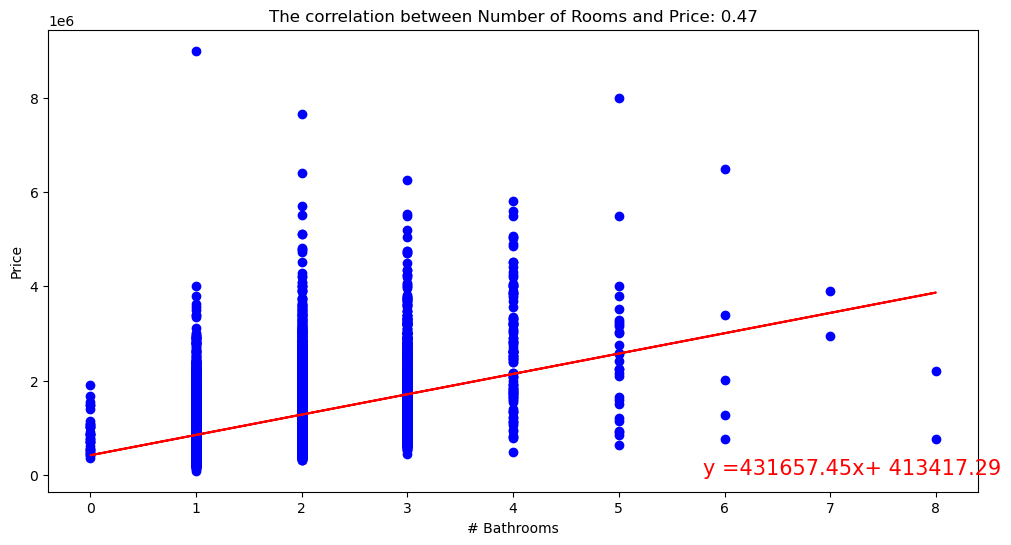

In [104]:
#linear regression model
slope, intercept, r_value, p_value, std_err = stats.linregress(melhousingclean_df['Bathroom'], melhousingclean_df['Price'])

#to create the plot
x_values = melhousingclean_df['Bathroom']
y_values = slope * x_values + intercept
line_eq= "y ="+ str(round(slope,2)) + "x+ " + str(round(intercept,2))

plt.figure(figsize=(12, 6))
plt.scatter(melhousingclean_df['Bathroom'], melhousingclean_df['Price'], color='blue')
plt.plot(x_values, y_values, color='red')
plt.annotate(line_eq,(5.8,0.8),fontsize=15,color="red")
plt.title(f"The correlation between Number of Rooms and Price: {correlationbath:.2f}")
plt.xlabel('# Bathrooms')
plt.ylabel('Price')
print(f"The r-squared is: {r_value**2}")

plt.show()

# Part 3 Analysis - Wisdom

In [105]:
melhousing_df = Path("melb_data1.csv")

In [106]:
melhousing_df=pd.read_csv(melhousing_df)
melhousing_df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,03/12/16,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,04/03/17,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [107]:
melhousing_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
BuildingArea      7130
YearBuilt         8205
CouncilArea      12211
Lattitude        13580
Longtitude       13580
Regionname       13580
Propertycount    13580
dtype: int64

In [108]:
#Drop columns BuildingArea and YearBuilt
melhousingclean_df=melhousing_df.drop(["BuildingArea","YearBuilt"],axis=1)
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
CouncilArea      12211
Lattitude        13580
Longtitude       13580
Regionname       13580
Propertycount    13580
dtype: int64

In [109]:
# Forward fill missing values in column CouncilArea
melhousingclean_df["CouncilArea"]= melhousingclean_df["CouncilArea"].ffill
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
CouncilArea      13580
Lattitude        13580
Longtitude       13580
Regionname       13580
Propertycount    13580
dtype: int64

In [110]:
# Forward fill missing values in column CouncilArea
melhousingclean_df["CouncilArea"]= melhousingclean_df["CouncilArea"].ffill
melhousingclean_df.count()

Suburb           13580
Address          13580
Rooms            13580
Type             13580
Price            13580
Method           13580
SellerG          13580
Date             13580
Distance         13580
Postcode         13580
Bedroom2         13580
Bathroom         13580
Car              13518
Landsize         13580
CouncilArea      13580
Lattitude        13580
Longtitude       13580
Regionname       13580
Propertycount    13580
dtype: int64

In [111]:
# Chi-Square Test between 'Type' (Property Type) and 'Method' (Sales Method)

# Create a contingency table
contingency_table = pd.crosstab(melhousingclean_df['Type'], melhousingclean_df['Method'])

# Display the contingency table to see how the data is distributed
print(contingency_table)

Method    PI     S  SA    SP   VB
Type                             
h       1069  6507  66  1079  728
t        134   723   7   143  107
u        361  1792  19   481  364


In [112]:
# dof = (Number of Rows - 1) x (Number of Columns - 1)

# Calculate degrees of freedom
dof = (contingency_table.shape[0] - 1) * (contingency_table.shape[1] - 1)
dof

8

In [113]:
# Perform the Chi-Square test using scipy.stats
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# Print the chi-square statistic, p-value, and degrees of freedom
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"P-Value: {p_val}")
print(f"Degrees of Freedom: {dof}")

# Print the expected frequencies
print("Expected Frequencies Table:")
print(expected)

Chi-Square Statistic: 120.08519425521132
P-Value: 3.183702485154384e-22
Degrees of Freedom: 8
Expected Frequencies Table:
[[1088.2353461  6277.53151694   64.01384389 1184.95191458  834.2673785 ]
 [ 128.29867452  740.09631811    7.54698085  139.7011782    98.35684831]
 [ 347.46597938 2004.37216495   20.43917526  378.34690722  266.3757732 ]]


In [114]:
# Interpretation based on p-value
if p_val < 0.05:
    print("There is a significant association between Property Type and Sales Method (Reject H0)")
else:
    print("No significant association between Property Type and Sales Method (Fail to Reject H0)")

There is a significant association between Property Type and Sales Method (Reject H0)


In [115]:
# Determine the Critical Value
alpha = 0.05  # Significance level
critical_value = stats.chi2.ppf(1 - alpha, dof)

# Print the Chi-Square Statistic, Critical Value, and P-Value
print(f"Chi-Square Statistic: {chi2_stat}")
print(f"Critical Value: {critical_value}")
print(f"P-Value: {p_val}")

# Interpretation using Critical Value
if chi2_stat > critical_value:
    print("Chi-Square Statistic is greater than Critical Value: Reject the Null Hypothesis")
else:
    print("Chi-Square Statistic is less than or equal to Critical Value: Fail to Reject the Null Hypothesis")

Chi-Square Statistic: 120.08519425521132
Critical Value: 15.507313055865453
P-Value: 3.183702485154384e-22
Chi-Square Statistic is greater than Critical Value: Reject the Null Hypothesis


In [116]:
# Combine Latitude and Longitude
melhousingclean_df['Combined_Lat_Long'] = melhousingclean_df['Lattitude'] + melhousingclean_df['Longtitude']
melhousingclean_df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Combined_Lat_Long
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,03/12/16,2.5,3067,2,1,1.0,202,<bound method NDFrame.ffill of 0 <bound...,-37.7996,144.9984,Northern Metropolitan,4019,107.1988
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,2,1,0.0,156,<bound method NDFrame.ffill of 0 <bound...,-37.8079,144.9934,Northern Metropolitan,4019,107.1855
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,3,2,0.0,134,<bound method NDFrame.ffill of 0 <bound...,-37.8093,144.9944,Northern Metropolitan,4019,107.1851
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,04/03/17,2.5,3067,3,2,1.0,94,<bound method NDFrame.ffill of 0 <bound...,-37.7969,144.9969,Northern Metropolitan,4019,107.2000
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,3,1,2.0,120,<bound method NDFrame.ffill of 0 <bound...,-37.8072,144.9941,Northern Metropolitan,4019,107.1869


/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/s

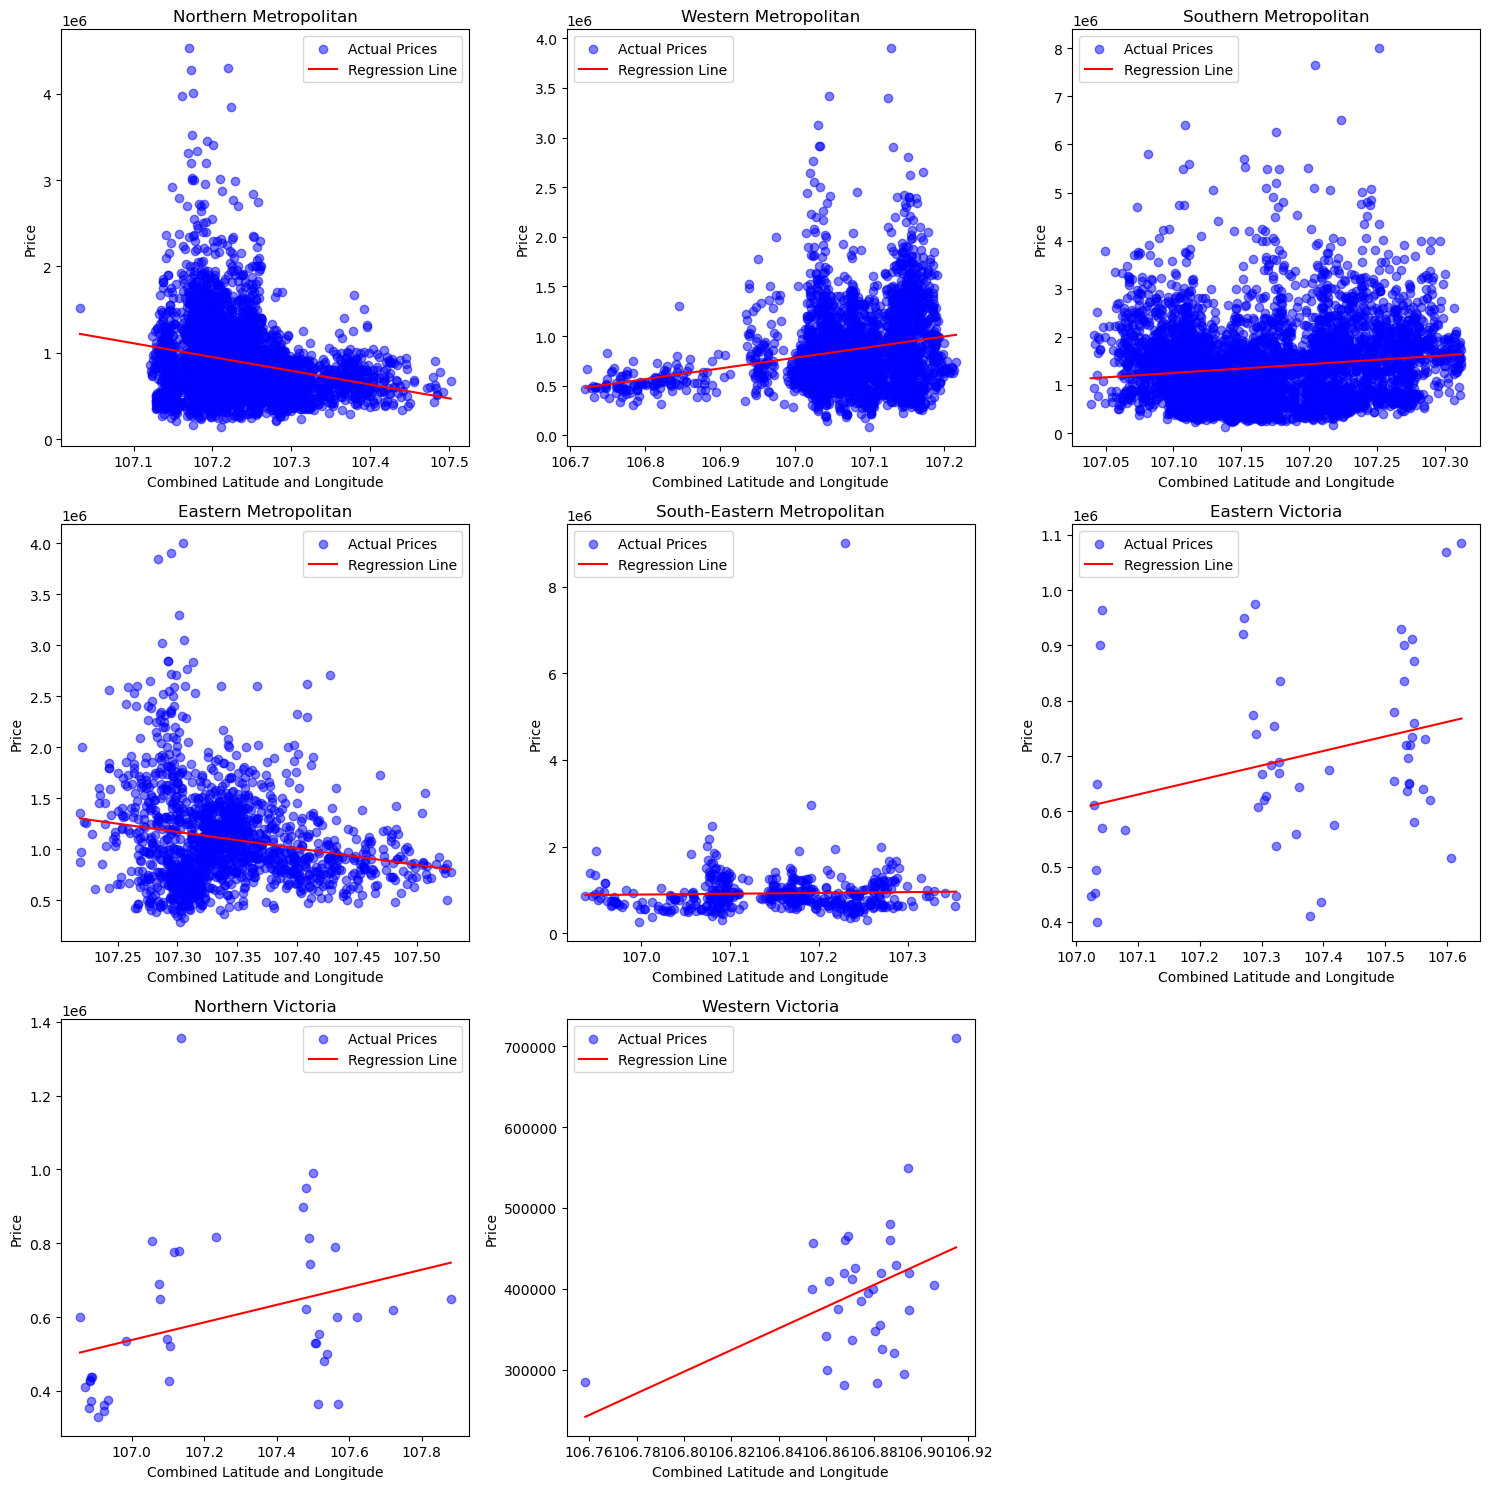

In [117]:

# Group Data by Regions and Prepare Scatter Plots
regions = melhousingclean_df['Regionname'].unique()

# Determine the number of subplots needed
num_regions = len(regions)
cols = 3
rows = (num_regions // cols) + (num_regions % cols > 0)

# Initialize the plot
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
axes = axes.flatten()

for i, region in enumerate(regions): 
    # Filter data for the region
    region_data = melhousingclean_df[melhousingclean_df['Regionname'] == region]
    
    # Prepare the combined data
    x_combined = region_data[['Combined_Lat_Long']]
    y = region_data['Price']
    
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(x_combined, y)
    
    # Generate predicted prices for the regression line
    x_range = np.linspace(x_combined.min(), x_combined.max(), 100).reshape(-1, 1)
    y_pred = model.predict(x_range)
    
    # Plot scatter and regression line
    axes[i].scatter(region_data['Combined_Lat_Long'], y, color='blue', alpha=0.5, label='Actual Prices')
    axes[i].plot(x_range, y_pred, color='red', label='Regression Line')
    axes[i].set_title(region)
    axes[i].set_xlabel('Combined Latitude and Longitude')
    axes[i].set_ylabel('Price')
    axes[i].legend()
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show plot
plt.tight_layout()
plt.show()

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/1091116351.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(regions))
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dev/lib/python3.10/site-packages/sklearn/base.py:493: U

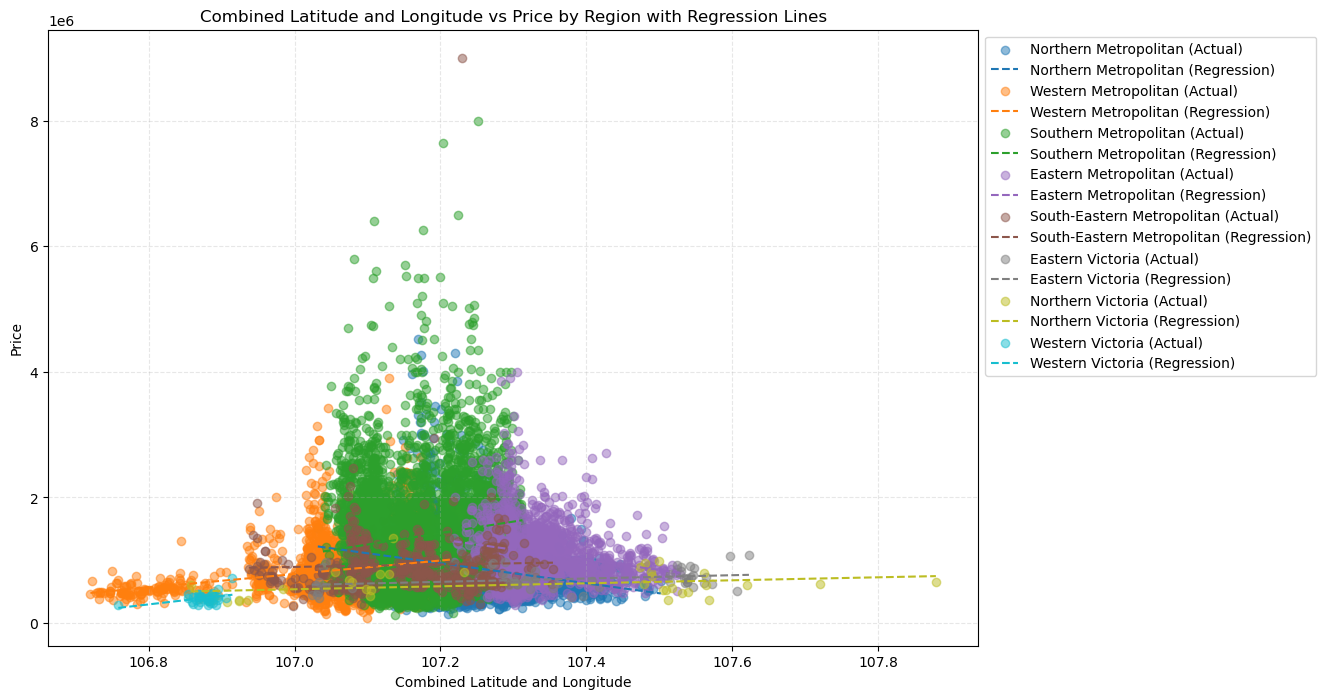

In [118]:
# Unique regions for color-coding
regions = melhousingclean_df['Regionname'].unique()
colors = plt.cm.get_cmap('tab10', len(regions))

# Initialize the plot
plt.figure(figsize=(12, 8))

# Loop through each region, fit regression, and plot
for i, region in enumerate(regions):
    # Filter data for the region
    region_data = melhousingclean_df[melhousingclean_df['Regionname'] == region]
    
    # Prepare the combined data
    X_combined = region_data[['Combined_Lat_Long']]
    y = region_data['Price']
    
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X_combined, y)
    
    # Generate predicted prices for the regression line
    X_range = np.linspace(X_combined.min(), X_combined.max(), 100).reshape(-1, 1)
    y_pred = model.predict(X_range)
    
    # Scatter plot for the region
    plt.scatter(X_combined, y, color=colors(i), alpha=0.5, label=f'{region} (Actual)')
    
    # Regression line for the region
    plt.plot(X_range, y_pred, color=colors(i), linestyle='--', label=f'{region} (Regression)')

# Set labels and title
plt.xlabel('Combined Latitude and Longitude')
plt.ylabel('Price')
plt.title('Combined Latitude and Longitude vs Price by Region with Regression Lines')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.3)

# Show the plot
plt.show()

In [119]:
# Set the 'Date' column in datetime format
melhousingclean_df['Date'] = pd.to_datetime(melhousingclean_df['Date'])

# Extract Month and Quarter from the Date
melhousingclean_df['Month'] = melhousingclean_df['Date'].dt.month
melhousingclean_df['Quarter'] = melhousingclean_df['Date'].dt.quarter

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/2419151877.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melhousingclean_df['Date'] = pd.to_datetime(melhousingclean_df['Date'])


In [120]:
# Calculate Average Prices by Month and Quarter
average_price_by_month = melhousingclean_df.groupby('Month')['Price'].mean().reset_index()
average_price_by_quarter = melhousingclean_df.groupby('Quarter')['Price'].mean().reset_index()

# Display the average prices
print("Average Price by Month:")
print(average_price_by_month)

print("\nAverage Price by Quarter:")
print(average_price_by_quarter)

Average Price by Month:
    Month         Price
0       1  9.397921e+05
1       2  1.169051e+06
2       3  1.146762e+06
3       4  1.050479e+06
4       5  1.097807e+06
5       6  1.068981e+06
6       7  9.314698e+05
7       8  1.056371e+06
8       9  1.126349e+06
9      10  1.135970e+06
10     11  1.142503e+06
11     12  1.144737e+06

Average Price by Quarter:
   Quarter         Price
0        1  1.121940e+06
1        2  1.074564e+06
2        3  1.026398e+06
3        4  1.140803e+06


/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/205418168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_price_by_month, x='Month', y='Price', palette='Blues')


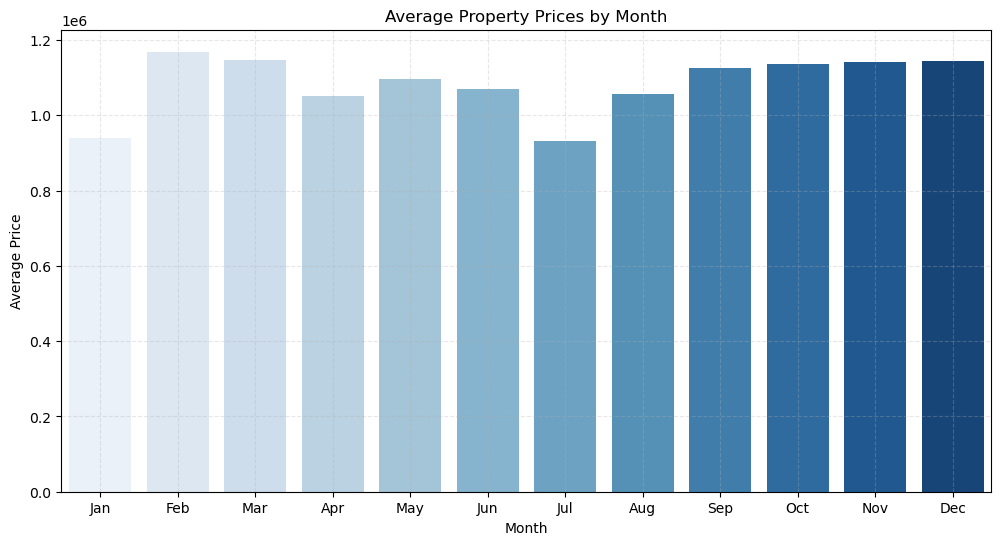

/var/folders/df/dwj7lm7s3vzgwfn_gv80jsqw0000gn/T/ipykernel_17471/205418168.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_price_by_quarter, x='Quarter', y='Price', palette='Greens')


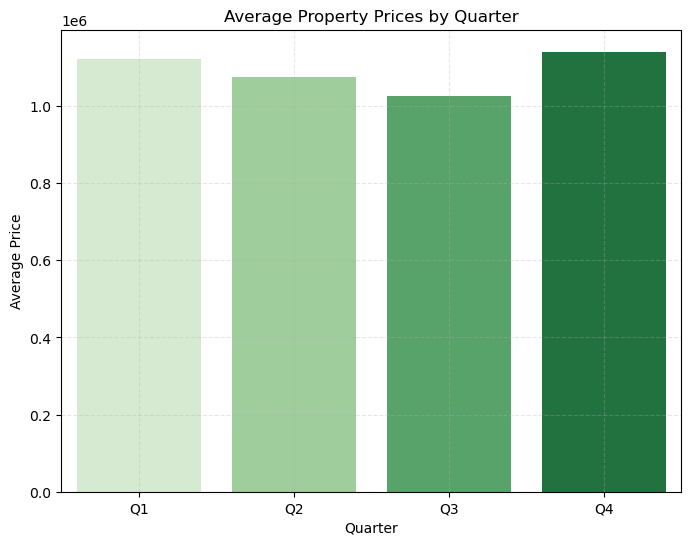

In [121]:
# Average Prices by Month
plt.figure(figsize=(12, 6))
sns.barplot(data=average_price_by_month, x='Month', y='Price', palette='Blues')
plt.title('Average Property Prices by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Average Prices by Quarter
plt.figure(figsize=(8, 6))
sns.barplot(data=average_price_by_quarter, x='Quarter', y='Price', palette='Greens')
plt.title('Average Property Prices by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.show()

In [122]:
# Convert Date to datetime
melhousingclean_df['Date'] = pd.to_datetime(melhousingclean_df['Date'])

# Extract year and month for trend analysis
melhousingclean_df['YearMonth'] = melhousingclean_df['Date'].dt.to_period('M')

# Group by Region and Year-Month to see how property counts are changing
property_count_over_time = melhousingclean_df.groupby(['Regionname', 'YearMonth']).size().reset_index(name='Property_Count')

# Identify regions with increasing property counts (suggestive of development booms)
# Calculate the change over the last few months or years to identify growth
property_growth = property_count_over_time.groupby('Regionname')['Property_Count'].pct_change().fillna(0)

# Add the growth data to the original DataFrame
property_count_over_time['Growth'] = property_growth

# Display the property count over time with growth data
print(property_count_over_time.head())

             Regionname YearMonth  Property_Count    Growth
0  Eastern Metropolitan   2016-03              38  0.000000
1  Eastern Metropolitan   2016-04              49  0.289474
2  Eastern Metropolitan   2016-05              55  0.122449
3  Eastern Metropolitan   2016-06              50 -0.090909
4  Eastern Metropolitan   2016-07              63  0.260000


In [123]:
# Group data by Region to get overall statistics
regional_data = melhousingclean_df.groupby('Regionname').agg(
    Avg_Price=('Price', 'mean'),
    Avg_Landsize=('Landsize', 'mean'),
    Total_Properties=('Price', 'count')
).reset_index()

# Merge with property growth data to identify regions with development booms
growth_and_regional_data = pd.merge(
    property_count_over_time.groupby('Regionname').tail(1),  # Get the most recent growth data
    regional_data,
    on='Regionname'
)

# Sort by the highest growth to find booming regions
booming_regions = growth_and_regional_data.sort_values(by='Growth', ascending=False)

# Display the booming regions
print("Regions Experiencing Development Booms:")
print(booming_regions.head())

Regions Experiencing Development Booms:
                   Regionname YearMonth  Property_Count     Growth  \
4  South-Eastern Metropolitan   2017-12              28  13.000000   
0        Eastern Metropolitan   2017-12              71   6.100000   
5       Southern Metropolitan   2017-12             124   2.875000   
2       Northern Metropolitan   2017-12              79   0.975000   
6        Western Metropolitan   2017-12              73   0.921053   

      Avg_Price  Avg_Landsize  Total_Properties  
4  9.229438e+05    613.991111               450  
0  1.104080e+06    634.133923              1471  
5  1.372963e+06    509.252183              4695  
2  8.981711e+05    568.948072              3890  
6  8.664205e+05    493.606852              2948  


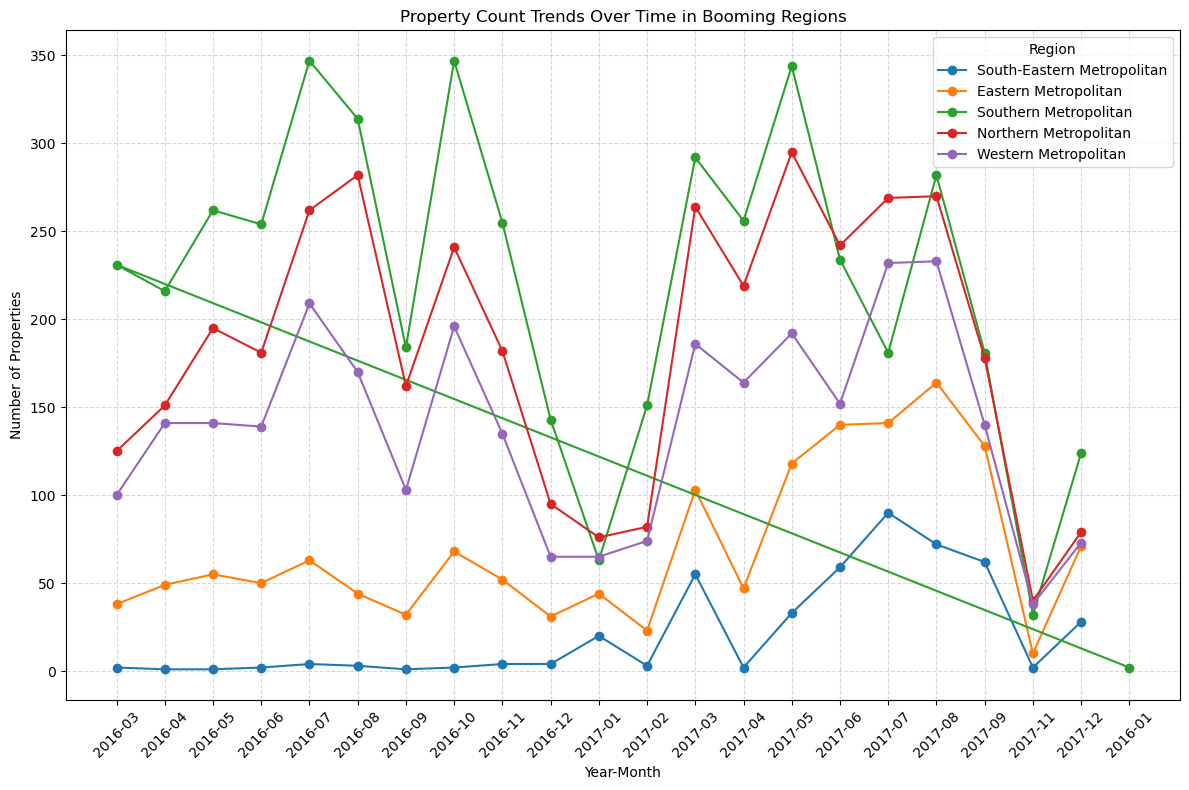

In [124]:
# Line plot to show property count trends for a few regions
top_regions = booming_regions['Regionname'].head(5)

plt.figure(figsize=(12, 8))

for region in top_regions:
    region_data = property_count_over_time[property_count_over_time['Regionname'] == region]
    plt.plot(region_data['YearMonth'].astype(str), region_data['Property_Count'], marker='o', label=region)

plt.title('Property Count Trends Over Time in Booming Regions')
plt.xlabel('Year-Month')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Part 4 Analysis - Mohammad

In [125]:
melhousing_data = melhousingclean_df[(melhousingclean_df["Type"] == "h") & (melhousingclean_df["Rooms"] <= 2) & (melhousingclean_df["Bedroom2"] == 2) & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data.head()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
0,Abbotsford,h,2.5,2,2,1,202,1.0,1480000
13,Abbotsford,h,2.5,2,2,1,195,1.0,1172500
19,Abbotsford,h,2.5,2,2,1,150,1.0,890000
24,Abbotsford,h,2.5,2,2,2,124,1.0,1100000
37,Abbotsford,h,2.5,2,2,1,172,1.0,1030000


In [126]:
#Linear Regression between Type of House vs Price
def plot_linear_regression(x_values,y_values,title,text_coordinates):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = x_values * slope + intercept
    line_eq = "y = " + str(round(slope, 2)) + " x + " + str(round(intercept, 2))
    plt.scatter(x_values, y_values)
    plt.plot(x_values, regress_values, "r-")
    plt.annotate(line_eq, text_coordinates, fontsize=15, color="red")
    print(f"The r-squared is: {rvalue**2}")
    plt.show()

The r-squared is: 0.10708291059975715


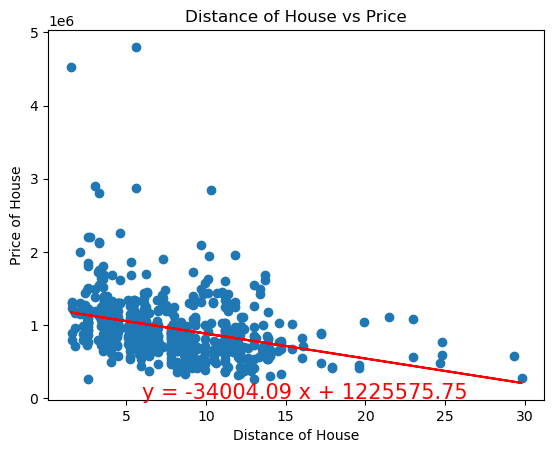

In [127]:
x_values = melhousing_data["Distance"]
y_values = melhousing_data["Price"]
plt.title("Distance of House vs Price")
plt.xlabel("Distance of House")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "Distance of House vs Price", (6, 30))

In [128]:
melhousing_data1 = melhousingclean_df[(melhousingclean_df["Type"] == "u") & (melhousingclean_df["Rooms"] <= 2) & (melhousingclean_df["Bedroom2"] == 2) & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data1.head()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
10,Abbotsford,u,2.5,2,2,2,0,1.0,700000
12,Abbotsford,u,2.5,2,2,2,0,1.0,750000
23,Abbotsford,u,2.5,2,2,1,0,1.0,500000
44,Airport West,u,13.5,2,2,1,168,1.0,500000
49,Airport West,u,13.5,2,2,1,141,1.0,515000


The r-squared is: 0.026614816974144365


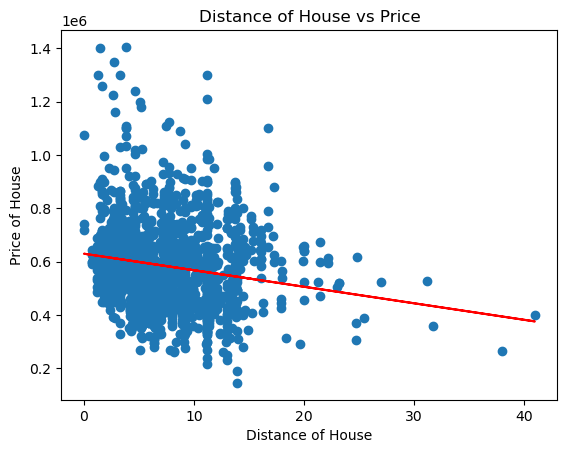

In [129]:
x_values = melhousing_data1["Distance"]
y_values = melhousing_data1["Price"]
plt.title("Distance of House vs Price")
plt.xlabel("Distance of House")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "Distance of House vs Price", (6, 30))

In [130]:
melhousing_data2 = melhousingclean_df[(melhousingclean_df["Type"] == "h") & (melhousingclean_df["Rooms"] > 2) & (melhousingclean_df["Bedroom2"] >2) & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data2.head()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
3,Abbotsford,h,2.5,3,3,2,94,1.0,850000
16,Abbotsford,h,2.5,3,3,2,113,1.0,1200000
27,Abbotsford,h,2.5,3,3,3,166,1.0,1447500
30,Abbotsford,h,2.5,4,4,3,0,1.0,1542000
32,Abbotsford,h,2.5,3,3,1,168,1.0,1290000


The r-squared is: 0.19834004935978322


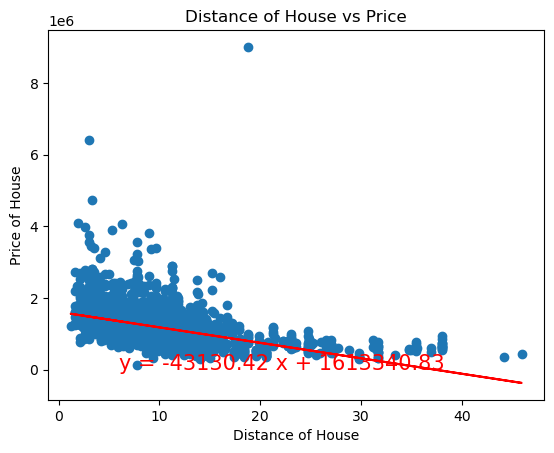

In [131]:
x_values = melhousing_data2["Distance"]
y_values = melhousing_data2["Price"]
plt.title("Distance of House vs Price")
plt.xlabel("Distance of House")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "Distance of House vs Price", (6, 30))

In [132]:
melhousing_data3 = melhousingclean_df[(melhousingclean_df["Type"] == "u") & (melhousingclean_df["Rooms"] > 2) & (melhousingclean_df["Bedroom2"] >2) & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data3.tail()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
12430,Albion,u,10.5,3,3,1,284,1.0,675000
12434,Ascot Vale,u,4.3,3,3,2,3215,1.0,870000
12718,Essendon North,u,8.2,3,3,2,292,1.0,1170000
12853,Surrey Hills,u,10.2,3,3,2,270,1.0,1290000
13164,Donvale,u,16.1,3,3,2,294,1.0,775000


The r-squared is: 0.19274936553861424


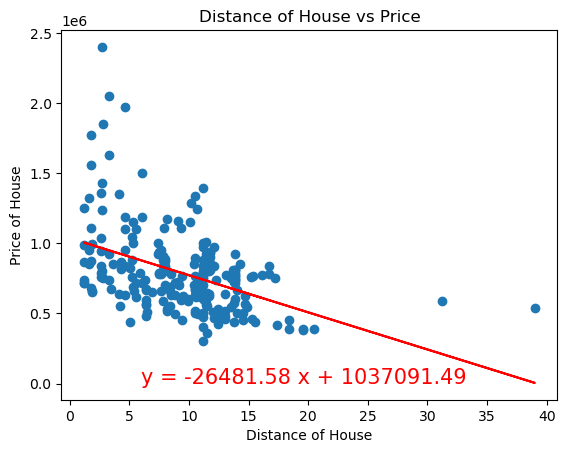

In [133]:
x_values = melhousing_data3["Distance"]
y_values = melhousing_data3["Price"]
plt.title("Distance of House vs Price")
plt.xlabel("Distance of House")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "Distance of House vs Price", (6, 30))

In [134]:
melhousing_data3 = melhousingclean_df[(melhousingclean_df["Type"] == "h") & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data3.tail()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
13562,Thornbury,h,7.0,3,3,1,312,1.0,1450000
13564,Tullamarine,h,12.9,3,3,1,607,1.0,540000
13572,Watsonia,h,14.5,2,2,1,210,1.0,650000
13573,Werribee,h,14.7,4,4,2,662,1.0,635000
13579,Yarraville,h,6.3,4,4,1,362,1.0,1285000


The r-squared is: 0.06556677819197258


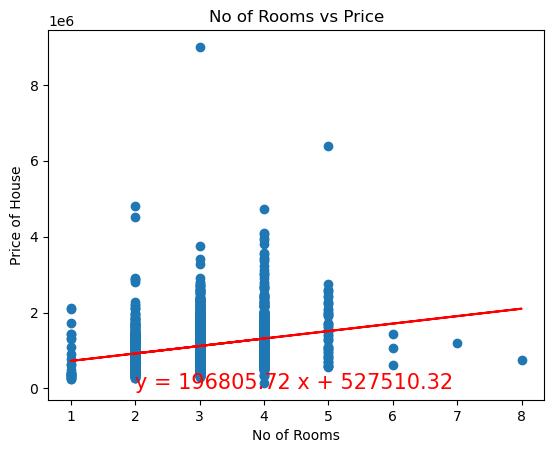

In [135]:
x_values = melhousing_data3["Rooms"]
y_values = melhousing_data3["Price"]
plt.title("No of Rooms vs Price")
plt.xlabel("No of Rooms")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "No of Rooms vs Price", (2, 30))

In [136]:
melhousing_data4 = melhousingclean_df[(melhousingclean_df["Type"] == "u") & (melhousingclean_df["Car"] == 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data4.tail()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
13449,Highett,u,16.0,2,2,1,158,1.0,680500
13453,Hoppers Crossing,u,18.4,2,2,1,150,1.0,315000
13482,Malvern East,u,8.4,2,2,1,129,1.0,651000
13495,Moonee Ponds,u,6.2,2,2,1,1475,1.0,435000
13510,Nunawading,u,15.4,2,2,1,903,1.0,710000


The r-squared is: 0.2923350562770317


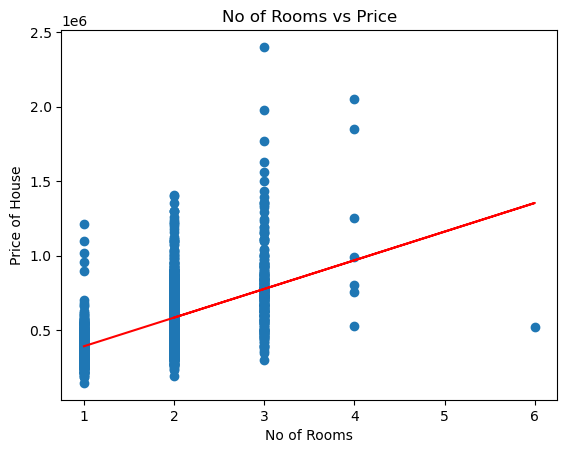

In [137]:
x_values = melhousing_data4["Rooms"]
y_values = melhousing_data4["Price"]
plt.title("No of Rooms vs Price")
plt.xlabel("No of Rooms")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "No of Rooms vs Price", (3, 30))

In [138]:
melhousing_data5 = melhousingclean_df[(melhousingclean_df["Type"] == "h") & (melhousingclean_df["Car"] > 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data5.head()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
4,Abbotsford,h,2.5,4,3,1,120,2.0,1600000
7,Abbotsford,h,2.5,2,2,1,256,2.0,1636000
9,Abbotsford,h,2.5,2,3,1,220,2.0,1097000
11,Abbotsford,h,2.5,3,3,2,214,2.0,1350000
15,Abbotsford,h,2.5,2,2,1,238,2.0,1310000


The r-squared is: 0.11743329741418511


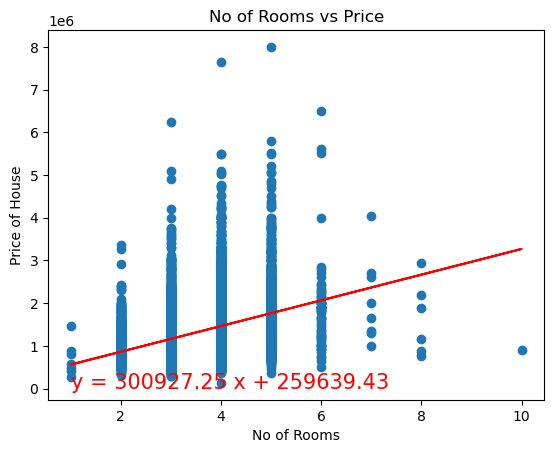

In [139]:
x_values = melhousing_data5["Rooms"]
y_values = melhousing_data5["Price"]
plt.title("No of Rooms vs Price")
plt.xlabel("No of Rooms")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "No of Rooms vs Price", (1, 10))

In [140]:
melhousing_data6 = melhousingclean_df[(melhousingclean_df["Type"] == "u") & (melhousingclean_df["Car"] > 1)][["Suburb", "Type", "Distance", "Rooms", "Bedroom2", "Bathroom", "Landsize", "Car", "Price"]]
melhousing_data6.head()

,Suburb,Type,Distance,Rooms,Bedroom2,Bathroom,Landsize,Car,Price
22,Abbotsford,u,2.5,3,3,2,4290,2.0,1090000
147,Altona,u,13.8,3,2,1,311,2.0,630000
156,Altona,u,13.8,2,2,1,115,2.0,425000
157,Altona,u,13.8,3,3,2,230,2.0,605000
177,Altona,u,13.8,3,3,1,181,2.0,605000


The r-squared is: 0.08951447296287986


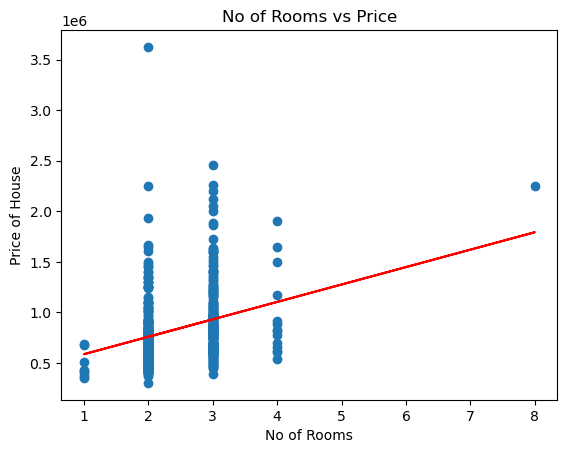

In [141]:
x_values = melhousing_data6["Rooms"]
y_values = melhousing_data6["Price"]
plt.title("No of Rooms vs Price")
plt.xlabel("No of Rooms")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "No of Rooms vs Price", (1, 10))

In [ ]:
x_values = melhousingclean_df["Distance"]
y_values = melhousingclean_df["Price"]
plt.title("Distance of House vs Price")
plt.xlabel("Distance of House")
plt.ylabel("Price of House")
plot_linear_regression(x_values, y_values, "Distance of House vs Price", (6, 30))

In [ ]:
# Create a contingency table for LandSize vs Price
#Lansize_Price_heatmap_data = pd.crosstab(melhousingclean_df['Landsize'], melhousingclean_df['Price'])

# Generate the heatmap
#plt.figure(figsize=(12, 8))
#sns.heatmap(Lansize_Price_heatmap_data, cmap='YlGnBu', annot=True, fmt='d')
#plt.title("Landsize vs Price")
#plt.xlabel("Land Size")
#plt.ylabel("Price")
#plt.show()

In [ ]:
# Create a contingency table for RegionName vs. Type
#region_type_heatmap_data = pd.crosstab(melhousingclean_df['Regionname'], melhousingclean_df['Type'])

# Generate the heatmap
#plt.figure(figsize=(12, 8))
#sns.heatmap(region_type_heatmap_data, cmap='YlGnBu', annot=True, fmt='d')
#plt.title("Property Distribution by Region and Type")
#plt.xlabel("Property Type")
#plt.ylabel("Region")
#plt.show()

In [ ]:
#import plotly.express as px
#fig = px.scatter_mapbox(melhousingclean_df,
                        #lat="Lattitude",
                        #lon="Longtitude",
                        ##color="Regionname",
                        #zoom=10,
                        #height=600)

#fig.update_layout(mapbox_style="open-street-map")

#fig.show()

In [ ]:
#import plotly.express as px
#fig = px.scatter_mapbox(melhousingclean_df,
                        #lat="Lattitude",
                        #lon="Longtitude",
                        #color="Suburb",
                        #zoom=10,
                        #height=600)

#fig.update_layout(mapbox_style="open-street-map")

#fig.show()